In [4]:
import pandas as pd
from pathlib import Path

clean_path = Path('../data/interim/taxi_2024_xsv_cleaned.csv')
print('Cleaned dataset file:', clean_path)
print('Exists:', clean_path.exists())

# Load the dataset and inspect basic structure
if clean_path.exists():
    df = pd.read_csv(clean_path, parse_dates=['Trip Start Timestamp', 'Trip End Timestamp'], low_memory=False)
    print('Shape:', df.shape)
    print('\nColumns:')
    print(df.columns.tolist())
    print('\nData types:')
    print(df.dtypes)
    print('\nFirst 5 rows:')
    display(df.head())
else:
    print('File not found. Please check the path.')


Cleaned dataset file: ../data/interim/taxi_2024_xsv_cleaned.csv
Exists: True


/var/folders/dy/nclg91xj2hs9nnr3bq4677q40000gn/T/ipykernel_21931/237323757.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(clean_path, parse_dates=['Trip Start Timestamp', 'Trip End Timestamp'], low_memory=False)
/var/folders/dy/nclg91xj2hs9nnr3bq4677q40000gn/T/ipykernel_21931/237323757.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(clean_path, parse_dates=['Trip Start Timestamp', 'Trip End Timestamp'], low_memory=False)


Shape: (6300899, 19)

Columns:
['Trip Start Timestamp', 'Trip End Timestamp', 'Trip Seconds', 'Trip Miles', 'Pickup Census Tract', 'Dropoff Census Tract', 'Pickup Community Area', 'Dropoff Community Area', 'Fare', 'Tips', 'Tolls', 'Extras', 'Trip Total', 'Payment Type', 'Company', 'Pickup Centroid Latitude', 'Pickup Centroid Longitude', 'Dropoff Centroid Latitude', 'Dropoff Centroid Longitude']

Data types:
Trip Start Timestamp          datetime64[us]
Trip End Timestamp            datetime64[us]
Trip Seconds                         float64
Trip Miles                               str
Pickup Census Tract                  float64
Dropoff Census Tract                 float64
Pickup Community Area                float64
Dropoff Community Area               float64
Fare                                     str
Tips                                     str
Tolls                                    str
Extras                                   str
Trip Total                               str
Paym

,Trip Start Timestamp,Trip End Timestamp,Trip Seconds,Trip Miles,Pickup Census Tract,Dropoff Census Tract,Pickup Community Area,Dropoff Community Area,Fare,Tips,Tolls,Extras,Trip Total,Payment Type,Company,Pickup Centroid Latitude,Pickup Centroid Longitude,Dropoff Centroid Latitude,Dropoff Centroid Longitude
0,2024-12-31 23:45:00,2025-01-01 00:15:00,1.217,"14,77",NaN,NaN,49.0,8.0,"$37,00","$0,00","$0,00","$0,00","$37,00",Prcard,City Service,"41,706587882","-87,623366512","41,899602111","-87,633308037"
1,2024-12-31 23:45:00,2025-01-01 00:15:00,1.444,"9,99",NaN,NaN,76.0,NaN,"$26,00","$0,00","$0,00","$6,00","$32,00",Cash,Sun Taxi,"41,980264315","-87,913624596",NaN,NaN
2,2024-12-31 23:45:00,2025-01-01 00:00:00,905.000,"6,18",NaN,NaN,8.0,3.0,"$19,00","$0,00","$0,00","$0,00","$19,00",Cash,Choice Taxi Association Inc,"41,899602111","-87,633308037","41,96581197","-87,655878786"
3,2024-12-31 23:45:00,2024-12-31 23:45:00,1.000,0,NaN,NaN,24.0,24.0,"$50,00","$0,00","$0,00","$0,00","$50,50",Credit Card,Flash Cab,"41,901206994","-87,676355989","41,901206994","-87,676355989"
4,2024-12-31 23:45:00,2025-01-01 00:00:00,1.214,"9,3",NaN,NaN,76.0,NaN,"$24,50","$0,00","$0,00","$16,00","$40,50",Cash,5 Star Taxi,"41,980264315","-87,913624596",NaN,NaN


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

TAXI_PATH = "../data/interim/taxi_2024_xsv_cleaned.csv"

Only use a sample, because the dataset is quite large. Remove nrows=1_000_000 to use the full dataset.

In [ ]:
usecols = [
    "Trip Start Timestamp",
    "Trip End Timestamp",
    "Trip Seconds",
    "Trip Miles",
    "Pickup Census Tract",
    "Dropoff Census Tract",
    "Pickup Community Area",
    "Dropoff Community Area",
    "Fare",
    "Tips",
    "Tolls",
    "Extras",
    "Trip Total",
    "Payment Type",
    "Company",
    "Pickup Centroid Latitude",
    "Pickup Centroid Longitude",
    "Dropoff Centroid Latitude",
    "Dropoff Centroid Longitude",
]

df = pd.read_csv(
    TAXI_PATH,
    usecols=usecols,
    dtype="string",
    nrows=1_000_000 # remove later if you want to use the full dataset
)

df.shape

(1000000, 19)

In [8]:
df = df.rename(columns={
    "Trip Start Timestamp": "trip_start",
    "Trip End Timestamp": "trip_end",
    "Trip Seconds": "trip_seconds_raw",
    "Trip Miles": "trip_miles_raw",
    "Pickup Census Tract": "pickup_census_tract",
    "Dropoff Census Tract": "dropoff_census_tract",
    "Pickup Community Area": "pickup_community_area",
    "Dropoff Community Area": "dropoff_community_area",
    "Fare": "fare_raw",
    "Tips": "tips_raw",
    "Tolls": "tolls_raw",
    "Extras": "extras_raw",
    "Trip Total": "trip_total_raw",
    "Payment Type": "payment_type",
    "Company": "company",
    "Pickup Centroid Latitude": "pickup_lat_raw",
    "Pickup Centroid Longitude": "pickup_lon_raw",
    "Dropoff Centroid Latitude": "dropoff_lat_raw",
    "Dropoff Centroid Longitude": "dropoff_lon_raw",
})

df.head()

,trip_start,trip_end,trip_seconds_raw,trip_miles_raw,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,fare_raw,tips_raw,tolls_raw,extras_raw,trip_total_raw,payment_type,company,pickup_lat_raw,pickup_lon_raw,dropoff_lat_raw,dropoff_lon_raw
0,12/31/2024 11:45:00 PM,01/01/2025 12:15:00 AM,1.217,"14,77",<NA>,<NA>,49,8,"$37,00","$0,00","$0,00","$0,00","$37,00",Prcard,City Service,"41,706587882","-87,623366512","41,899602111","-87,633308037"
1,12/31/2024 11:45:00 PM,01/01/2025 12:15:00 AM,1.444,"9,99",<NA>,<NA>,76,<NA>,"$26,00","$0,00","$0,00","$6,00","$32,00",Cash,Sun Taxi,"41,980264315","-87,913624596",<NA>,<NA>
2,12/31/2024 11:45:00 PM,01/01/2025 12:00:00 AM,905,"6,18",<NA>,<NA>,8,3,"$19,00","$0,00","$0,00","$0,00","$19,00",Cash,Choice Taxi Association Inc,"41,899602111","-87,633308037","41,96581197","-87,655878786"
3,12/31/2024 11:45:00 PM,12/31/2024 11:45:00 PM,1,0,<NA>,<NA>,24,24,"$50,00","$0,00","$0,00","$0,00","$50,50",Credit Card,Flash Cab,"41,901206994","-87,676355989","41,901206994","-87,676355989"
4,12/31/2024 11:45:00 PM,01/01/2025 12:00:00 AM,1.214,"9,3",<NA>,<NA>,76,<NA>,"$24,50","$0,00","$0,00","$16,00","$40,50",Cash,5 Star Taxi,"41,980264315","-87,913624596",<NA>,<NA>


transform datatypes

In [ ]:
def parse_seconds(series):
    return pd.to_numeric(
        series.astype("string").str.replace(".", "", regex=False),
        errors="coerce"
    )


def parse_euro_float(series):
    return pd.to_numeric(
        series.astype("string").str.replace(",", ".", regex=False),
        errors="coerce"
    )


def parse_money(series):
    return pd.to_numeric(
        series.astype("string")
        .str.replace("$", "", regex=False)
        .str.replace(",", ".", regex=False),
        errors="coerce"
    )

In [10]:
df["trip_start_dt"] = pd.to_datetime(
    df["trip_start"],
    format="%m/%d/%Y %I:%M:%S %p",
    errors="coerce"
)

df["trip_end_dt"] = pd.to_datetime(
    df["trip_end"],
    format="%m/%d/%Y %I:%M:%S %p",
    errors="coerce"
)

df["trip_seconds"] = parse_seconds(df["trip_seconds_raw"])
df["trip_miles"] = parse_euro_float(df["trip_miles_raw"])

df["fare"] = parse_money(df["fare_raw"])
df["tips"] = parse_money(df["tips_raw"])
df["tolls"] = parse_money(df["tolls_raw"])
df["extras"] = parse_money(df["extras_raw"])
df["trip_total"] = parse_money(df["trip_total_raw"])

df["pickup_lat"] = parse_euro_float(df["pickup_lat_raw"])
df["pickup_lon"] = parse_euro_float(df["pickup_lon_raw"])
df["dropoff_lat"] = parse_euro_float(df["dropoff_lat_raw"])
df["dropoff_lon"] = parse_euro_float(df["dropoff_lon_raw"])

df["pickup_census_tract"] = pd.to_numeric(df["pickup_census_tract"], errors="coerce")
df["dropoff_census_tract"] = pd.to_numeric(df["dropoff_census_tract"], errors="coerce")
df["pickup_community_area"] = pd.to_numeric(df["pickup_community_area"], errors="coerce")
df["dropoff_community_area"] = pd.to_numeric(df["dropoff_community_area"], errors="coerce")

In [11]:
df[[
    "trip_start_dt",
    "trip_seconds",
    "trip_miles",
    "fare",
    "trip_total",
    "pickup_lat",
    "pickup_lon"
]].head()

,trip_start_dt,trip_seconds,trip_miles,fare,trip_total,pickup_lat,pickup_lon
0,2024-12-31 23:45:00,1217,14.77,37.0,37.0,41.706588,-87.623367
1,2024-12-31 23:45:00,1444,9.99,26.0,32.0,41.980264,-87.913625
2,2024-12-31 23:45:00,905,6.18,19.0,19.0,41.899602,-87.633308
3,2024-12-31 23:45:00,1,0.0,50.0,50.5,41.901207,-87.676356
4,2024-12-31 23:45:00,1214,9.3,24.5,40.5,41.980264,-87.913625


In [12]:
print(f"Rows in loaded dataset: {len(df):,}")
print(f"Columns: {df.shape[1]}")

Rows in loaded dataset: 1,000,000
Columns: 32


In [13]:
print("Min trip start:", df["trip_start_dt"].min())
print("Max trip start:", df["trip_start_dt"].max())
print("Min trip end:", df["trip_end_dt"].min())
print("Max trip end:", df["trip_end_dt"].max())

Min trip start: 2024-11-01 19:00:00
Max trip start: 2024-12-31 23:45:00
Min trip end: 2024-11-01 19:00:00
Max trip end: 2025-01-03 17:45:00


In [14]:
missing = (
    df.isna()
    .mean()
    .sort_values(ascending=False)
    .to_frame("missing_share")
)

missing["missing_percent"] = missing["missing_share"] * 100

missing.head(30)

,missing_share,missing_percent
dropoff_census_tract,0.563593,56.3593
pickup_census_tract,0.549014,54.9014
dropoff_community_area,0.070060,7.0060
dropoff_lon,0.064657,6.4657
dropoff_lon_raw,0.064657,6.4657
dropoff_lat_raw,0.064657,6.4657
dropoff_lat,0.064657,6.4657
trip_total,0.002806,0.2806
fare,0.002806,0.2806
tolls,0.002692,0.2692


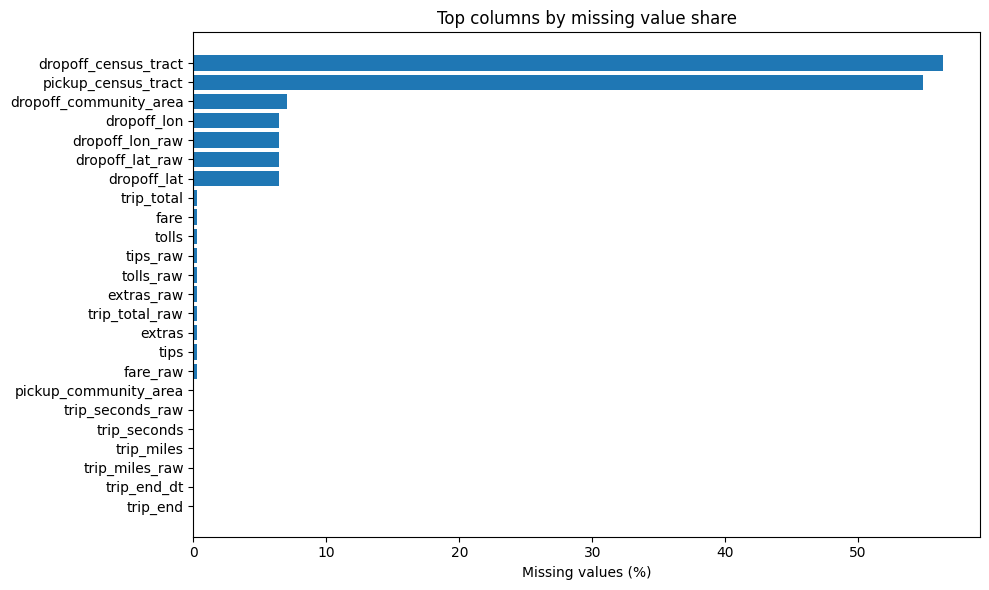

In [15]:
missing_plot = missing[missing["missing_percent"] > 0].head(25)

plt.figure(figsize=(10, 6))
plt.barh(missing_plot.index[::-1], missing_plot["missing_percent"][::-1])
plt.xlabel("Missing values (%)")
plt.title("Top columns by missing value share")
plt.tight_layout()
plt.show()

remove missing values and outliers

In [16]:
before = len(df)

df_clean = df[
    df["trip_start_dt"].notna()
    & df["pickup_lat"].notna()
    & df["pickup_lon"].notna()
    & (df["trip_seconds"] > 0)
    & (df["trip_miles"] >= 0)
    & (df["fare"] >= 0)
    & (df["trip_total"] >= 0)
    & (df["pickup_lat"].between(41.60, 42.10))
    & (df["pickup_lon"].between(-88.00, -87.40))
].copy()

after = len(df_clean)

print(f"Rows before cleaning: {before:,}")
print(f"Rows after cleaning: {after:,}")
print(f"Removed rows: {before - after:,}")
print(f"Removed share: {(before - after) / before * 100:.2f}%")

Rows before cleaning: 1,000,000
Rows after cleaning: 985,771
Removed rows: 14,229
Removed share: 1.42%


add time features

In [17]:
df_clean["date"] = df_clean["trip_start_dt"].dt.date
df_clean["month"] = df_clean["trip_start_dt"].dt.month
df_clean["day_of_week"] = df_clean["trip_start_dt"].dt.dayofweek
df_clean["day_name"] = df_clean["trip_start_dt"].dt.day_name()
df_clean["hour"] = df_clean["trip_start_dt"].dt.hour
df_clean["is_weekend"] = df_clean["day_of_week"].isin([5, 6]).astype(int)
df_clean["time_bucket_hour"] = df_clean["trip_start_dt"].dt.floor("h")

In [18]:
trips_by_month = (
    df_clean
    .groupby("month")
    .size()
    .reset_index(name="trips")
)

trips_by_month

,month,trips
0,11,502812
1,12,482959


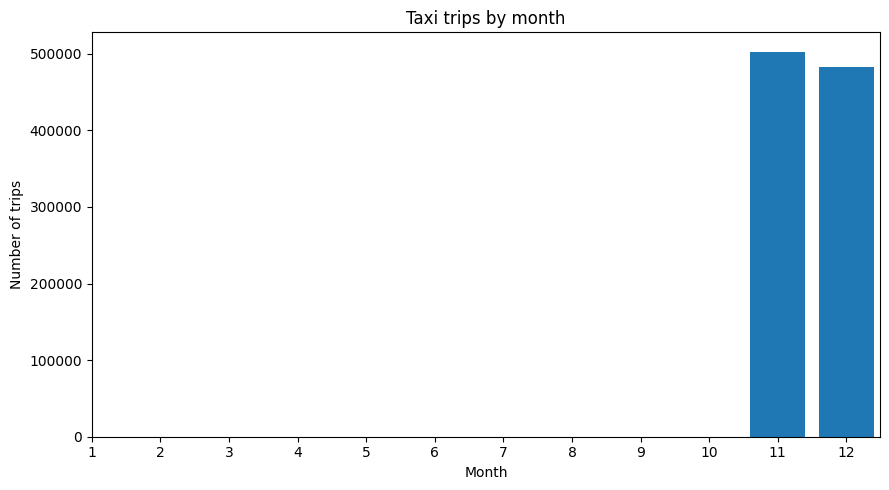

In [19]:
plt.figure(figsize=(9, 5))
plt.bar(trips_by_month["month"], trips_by_month["trips"])
plt.xlabel("Month")
plt.ylabel("Number of trips")
plt.title("Taxi trips by month")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

In [20]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

trips_by_weekday = (
    df_clean
    .groupby("day_name")
    .size()
    .reindex(weekday_order)
    .reset_index(name="trips")
)

trips_by_weekday

,day_name,trips
0,Monday,150414
1,Tuesday,156527
2,Wednesday,144829
3,Thursday,151020
4,Friday,147725
5,Saturday,121577
6,Sunday,113679


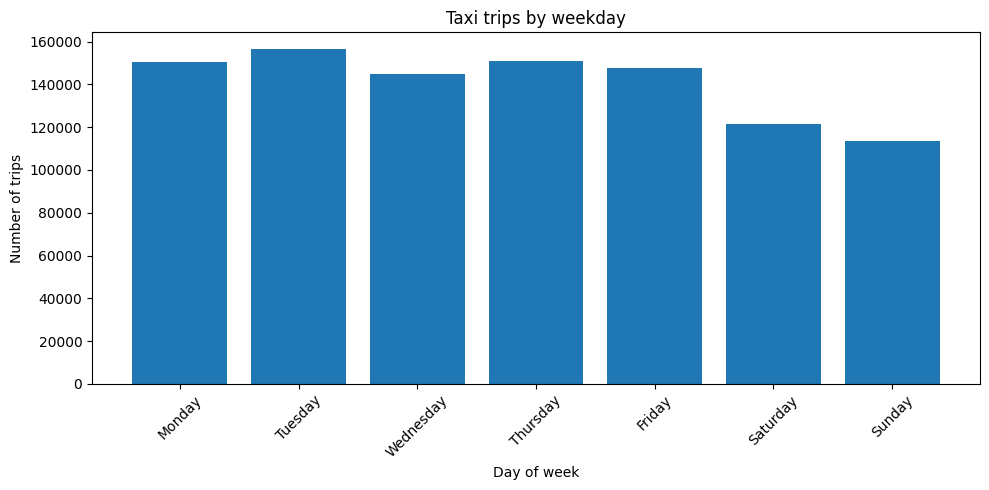

In [21]:
plt.figure(figsize=(10, 5))
plt.bar(trips_by_weekday["day_name"], trips_by_weekday["trips"])
plt.xlabel("Day of week")
plt.ylabel("Number of trips")
plt.title("Taxi trips by weekday")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
trips_by_hour = (
    df_clean
    .groupby("hour")
    .size()
    .reset_index(name="trips")
)

trips_by_hour

,hour,trips
0,0,14918
1,1,8277
2,2,4554
3,3,3650
4,4,5240
5,5,8810
6,6,18218
7,7,34258
8,8,50089
9,9,55930


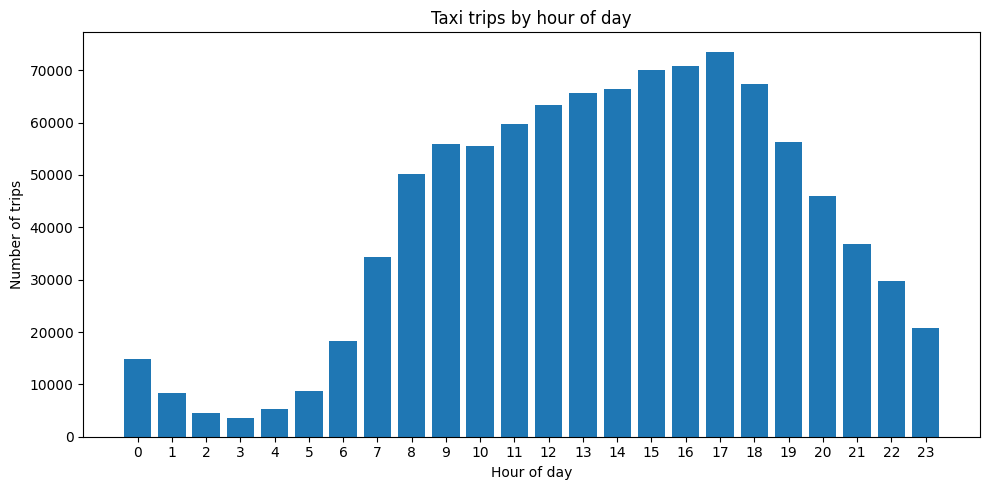

In [23]:
plt.figure(figsize=(10, 5))
plt.bar(trips_by_hour["hour"], trips_by_hour["trips"])
plt.xlabel("Hour of day")
plt.ylabel("Number of trips")
plt.title("Taxi trips by hour of day")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

In [24]:
hour_weekday = (
    df_clean
    .groupby(["day_of_week", "hour"])
    .size()
    .reset_index(name="trips")
)

heatmap_data = hour_weekday.pivot(
    index="day_of_week",
    columns="hour",
    values="trips"
).fillna(0)

heatmap_data.index = weekday_order
heatmap_data

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Monday,1945,974,409,385,804,1486,3140,5905,8811,9780,...,10513,11038,10889,10934,9566,7897,6305,4679,3537,2256
Tuesday,1821,908,390,344,719,1324,3036,6484,9750,10355,...,10784,11018,11475,11930,10409,8437,6717,4919,3905,2479
Wednesday,1329,599,315,332,661,1263,2847,6133,8681,9265,...,10013,10334,10320,10906,9631,8017,6597,5202,3855,2309
Thursday,1559,779,395,382,648,1334,2988,5897,8660,8756,...,9676,10785,11031,11517,10790,8376,6942,6236,5162,3469
Friday,2238,1153,511,407,727,1300,2811,5106,7057,7347,...,9737,10191,10149,10878,10434,9295,7353,6072,5135,3983
Saturday,2945,1879,1253,869,769,944,1535,2268,3438,5135,...,8315,8478,8648,9237,9070,7793,5988,5241,4586,3878
Sunday,3081,1985,1281,931,912,1159,1861,2465,3692,5292,...,7463,8126,8205,8158,7443,6505,5991,4444,3511,2466


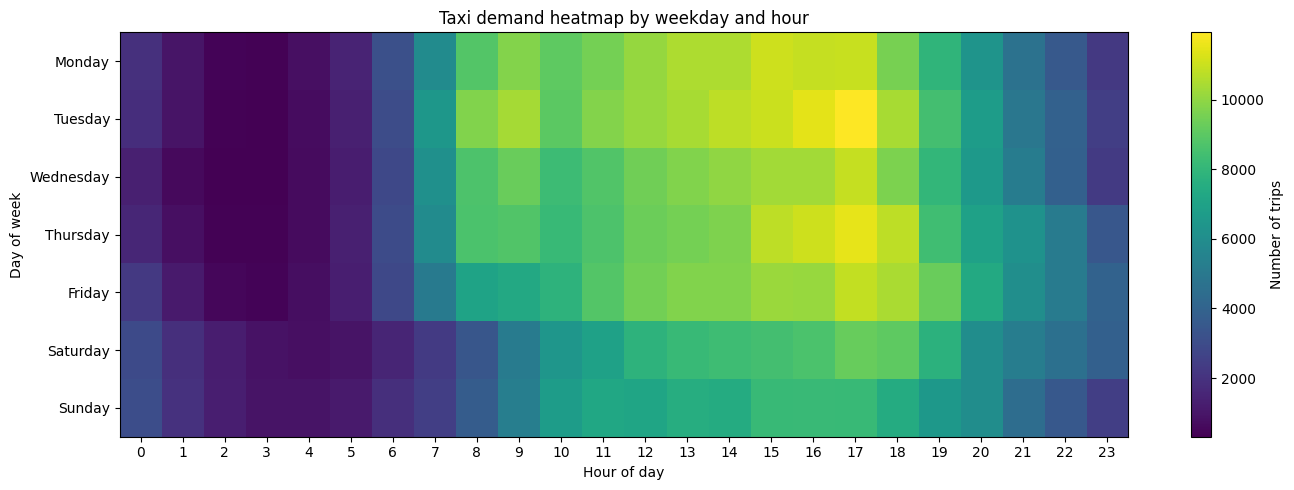

In [25]:
plt.figure(figsize=(14, 5))
plt.imshow(heatmap_data, aspect="auto")
plt.colorbar(label="Number of trips")
plt.xticks(ticks=np.arange(24), labels=np.arange(24))
plt.yticks(ticks=np.arange(7), labels=weekday_order)
plt.xlabel("Hour of day")
plt.ylabel("Day of week")
plt.title("Taxi demand heatmap by weekday and hour")
plt.tight_layout()
plt.show()

In [26]:
daily_trips = (
    df_clean
    .groupby("date")
    .size()
    .reset_index(name="trips")
)

daily_trips["date"] = pd.to_datetime(daily_trips["date"])

daily_trips.head()

,date,trips
0,2024-11-01,3130
1,2024-11-02,14689
2,2024-11-03,15339
3,2024-11-04,21253
4,2024-11-05,20422


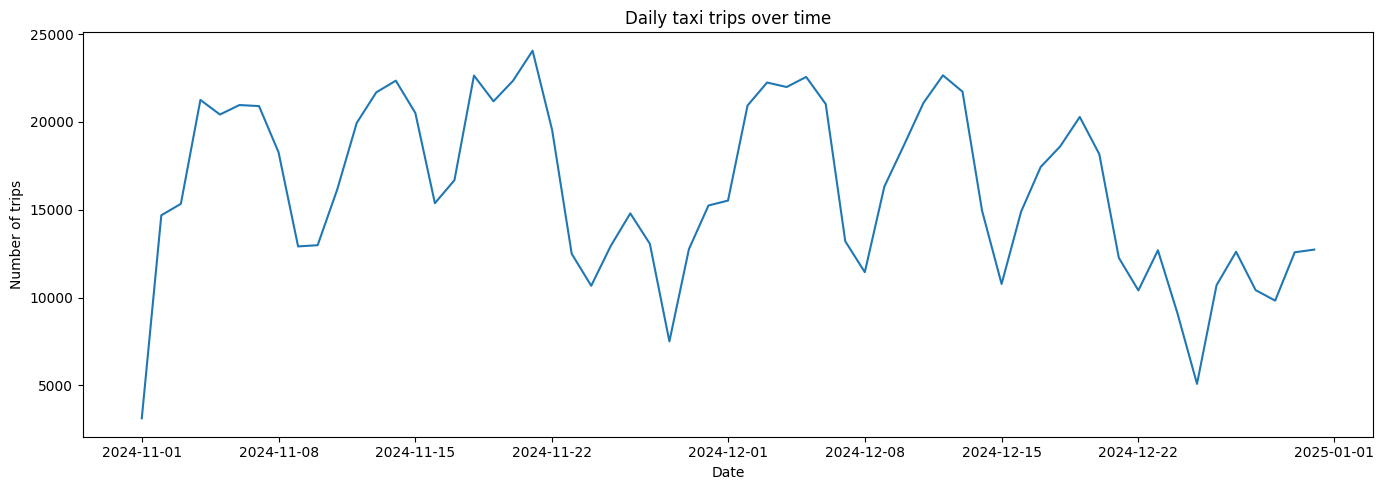

In [27]:
plt.figure(figsize=(14, 5))
plt.plot(daily_trips["date"], daily_trips["trips"])
plt.xlabel("Date")
plt.ylabel("Number of trips")
plt.title("Daily taxi trips over time")
plt.tight_layout()
plt.show()

In [28]:
numeric_summary_cols = [
    "trip_seconds",
    "trip_miles",
    "fare",
    "tips",
    "tolls",
    "extras",
    "trip_total"
]

summary = df_clean[numeric_summary_cols].describe(
    percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]
).T

summary

,count,mean,std,min,1%,5%,50%,95%,99%,max
trip_seconds,985771.0,1236.050531,1660.169655,1.0,5.0,94.0,909.0,3180.0,4575.0,86322.0
trip_miles,985771.0,6.756112,7.055467,0.0,0.0,0.0,3.35,18.29,26.43,288.41
fare,985771.0,22.083372,18.308681,0.0,3.25,4.75,15.25,51.0,72.25,975.0
tips,985771.0,2.85361,4.19203,0.0,0.0,0.0,0.86,11.1,15.98,150.0
tolls,985771.0,0.020214,0.371616,0.0,0.0,0.0,0.0,0.0,0.0,75.0
extras,985771.0,1.957005,5.816481,0.0,0.0,0.0,0.0,6.0,31.0,591.3
trip_total,985771.0,27.107601,23.509262,0.0,3.25,5.25,18.24,66.9,96.6,975.0


In [29]:
df_clean["trip_minutes"] = df_clean["trip_seconds"] / 60
df_clean["trip_minutes"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])

count     985771.0
mean     20.600842
std      27.669494
min       0.016667
1%        0.083333
5%        1.566667
50%          15.15
95%           53.0
99%          76.25
max         1438.7
Name: trip_minutes, dtype: Float64

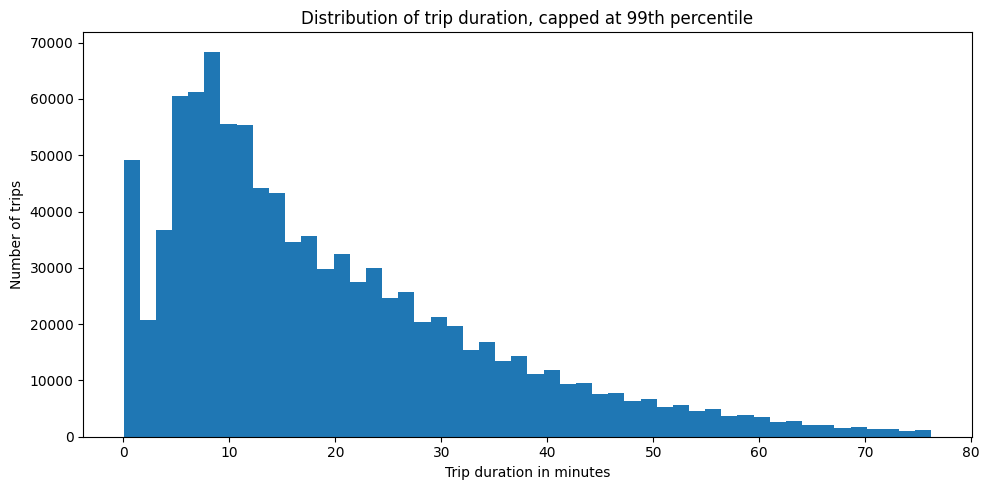

In [30]:
trip_minutes_plot = df_clean[
    df_clean["trip_minutes"].between(0, df_clean["trip_minutes"].quantile(0.99))
]

plt.figure(figsize=(10, 5))
plt.hist(trip_minutes_plot["trip_minutes"], bins=50)
plt.xlabel("Trip duration in minutes")
plt.ylabel("Number of trips")
plt.title("Distribution of trip duration, capped at 99th percentile")
plt.tight_layout()
plt.show()

In [31]:
df_clean["trip_miles"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])

count    985771.0
mean     6.756112
std      7.055467
min           0.0
1%            0.0
5%            0.0
50%          3.35
95%         18.29
99%         26.43
max        288.41
Name: trip_miles, dtype: Float64

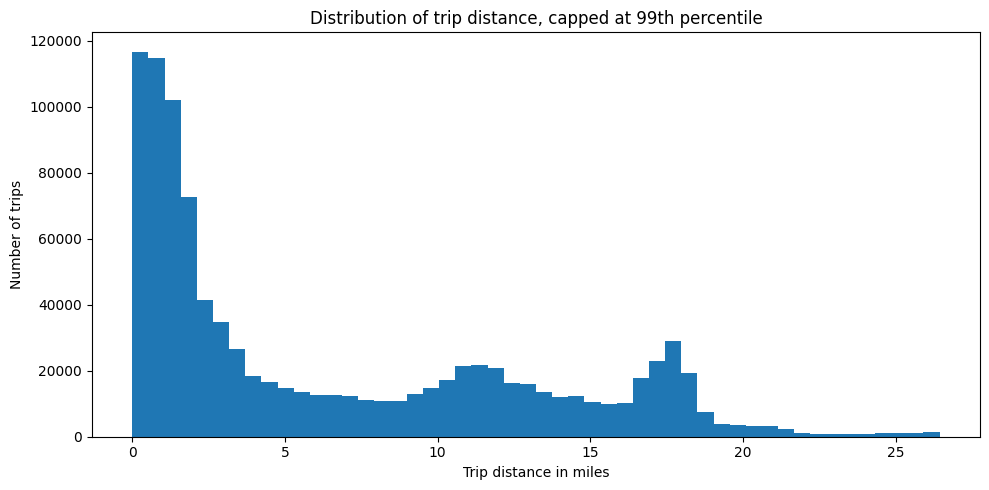

In [32]:
trip_miles_plot = df_clean[
    df_clean["trip_miles"].between(0, df_clean["trip_miles"].quantile(0.99))
]

plt.figure(figsize=(10, 5))
plt.hist(trip_miles_plot["trip_miles"], bins=50)
plt.xlabel("Trip distance in miles")
plt.ylabel("Number of trips")
plt.title("Distribution of trip distance, capped at 99th percentile")
plt.tight_layout()
plt.show()

Plausibility Checks

In [33]:
quality_checks = {
    "missing_trip_start": df["trip_start_dt"].isna().sum(),
    "missing_pickup_lat": df["pickup_lat"].isna().sum(),
    "missing_pickup_lon": df["pickup_lon"].isna().sum(),
    "trip_seconds_leq_0": (df["trip_seconds"] <= 0).sum(),
    "trip_miles_negative": (df["trip_miles"] < 0).sum(),
    "fare_negative": (df["fare"] < 0).sum(),
    "trip_total_negative": (df["trip_total"] < 0).sum(),
    "pickup_lat_outside_chicago": (~df["pickup_lat"].between(41.60, 42.10)).sum(),
    "pickup_lon_outside_chicago": (~df["pickup_lon"].between(-88.00, -87.40)).sum(),
}

quality_checks_df = pd.DataFrame.from_dict(
    quality_checks,
    orient="index",
    columns=["count"]
)

quality_checks_df["share_percent"] = quality_checks_df["count"] / len(df) * 100
quality_checks_df

,count,share_percent
missing_trip_start,0,0.0000
missing_pickup_lat,0,0.0000
missing_pickup_lon,0,0.0000
trip_seconds_leq_0,11281,1.1281
trip_miles_negative,0,0.0000
fare_negative,0,0.0000
trip_total_negative,0,0.0000
pickup_lat_outside_chicago,0,0.0000
pickup_lon_outside_chicago,0,0.0000


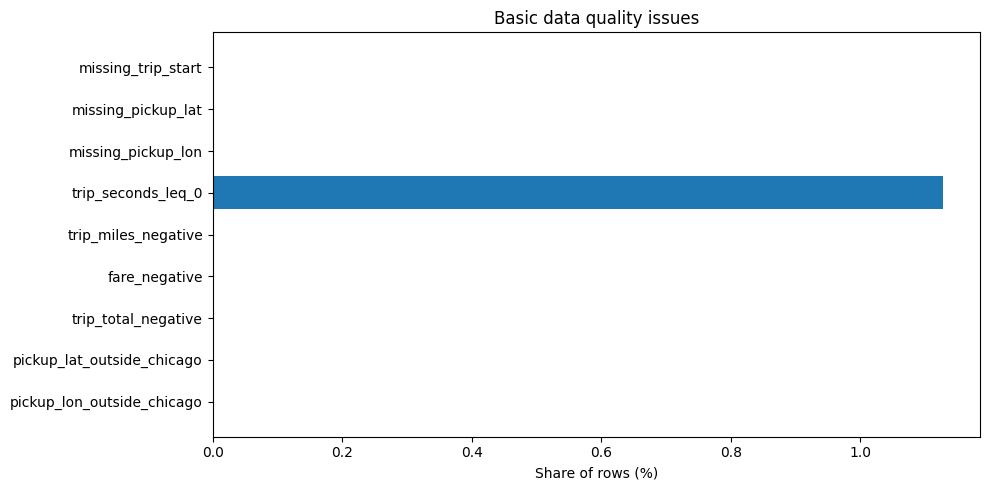

In [34]:
plt.figure(figsize=(10, 5))
plt.barh(quality_checks_df.index[::-1], quality_checks_df["share_percent"][::-1])
plt.xlabel("Share of rows (%)")
plt.title("Basic data quality issues")
plt.tight_layout()
plt.show()

there should be no negative trip durations

In [35]:
invalid_duration = df[df["trip_seconds"] <= 0].copy()

invalid_duration[
    [
        "trip_start_dt",
        "trip_end_dt",
        "trip_seconds",
        "trip_miles",
        "fare",
        "trip_total",
        "payment_type",
        "company",
        "pickup_community_area",
        "dropoff_community_area"
    ]
].head(20)

,trip_start_dt,trip_end_dt,trip_seconds,trip_miles,fare,trip_total,payment_type,company,pickup_community_area,dropoff_community_area
48,2024-12-31 23:45:00,2024-12-31 23:45:00,0,0.0,35.0,35.0,Credit Card,Taxi Affiliation Services,31,31
221,2024-12-31 23:15:00,2024-12-31 23:15:00,0,0.0,3.25,3.25,No Charge,Choice Taxi Association,32,32
403,2024-12-31 22:45:00,2024-12-31 22:45:00,0,0.0,3.25,3.25,Cash,Taxi Affiliation Services,8,8
515,2024-12-31 22:30:00,2024-12-31 22:30:00,0,0.0,3.25,5.25,Cash,Chicago City Taxi Association,76,<NA>
523,2024-12-31 22:30:00,2024-12-31 22:30:00,0,0.0,3.25,3.25,Cash,Taxi Affiliation Services,28,28
662,2024-12-31 22:00:00,2024-12-31 22:00:00,0,0.0,20.0,26.1,Credit Card,Taxi Affiliation Services,6,6
787,2024-12-31 21:45:00,2024-12-31 21:45:00,0,5.4,16.75,16.75,Cash,Taxi Affiliation Services,6,6
806,2024-12-31 21:45:00,2024-12-31 21:45:00,0,0.0,3.25,56.25,Credit Card,Taxi Affiliation Services,32,32
844,2024-12-31 21:45:00,2024-12-31 21:45:00,0,0.0,3.25,3.25,Cash,Taxi Affiliation Services,32,32
906,2024-12-31 21:30:00,2024-12-31 21:30:00,0,0.0,3.25,3.25,Cash,"Taxicab Insurance Agency, LLC",8,8


In [36]:
invalid_duration[["trip_seconds", "trip_miles", "fare", "trip_total"]].describe()

,trip_seconds,trip_miles,fare,trip_total
count,11281.0,11281.0,11270.0,11270.0
mean,0.0,0.264991,16.077285,20.240898
std,0.0,2.133113,28.275063,31.362525
min,0.0,0.0,0.0,0.0
25%,0.0,0.0,3.25,3.25
50%,0.0,0.0,3.25,6.75
75%,0.0,0.0,20.5675,29.3475
max,0.0,51.9,825.0,825.0


## temporal demand patterns

In [37]:
# Make sure timestamp is datetime
df_clean["trip_start_dt"] = pd.to_datetime(df_clean["trip_start_dt"], errors="coerce")

# Remove rows without valid start timestamp
df_temporal = df_clean[df_clean["trip_start_dt"].notna()].copy()

# Temporal features
df_temporal["date"] = df_temporal["trip_start_dt"].dt.date
df_temporal["date"] = pd.to_datetime(df_temporal["date"])

df_temporal["month"] = df_temporal["trip_start_dt"].dt.month
df_temporal["month_name"] = df_temporal["trip_start_dt"].dt.month_name()

df_temporal["day_of_week"] = df_temporal["trip_start_dt"].dt.dayofweek
df_temporal["day_name"] = df_temporal["trip_start_dt"].dt.day_name()

df_temporal["hour"] = df_temporal["trip_start_dt"].dt.hour
df_temporal["is_weekend"] = df_temporal["day_of_week"].isin([5, 6]).astype(int)

df_temporal["time_bucket_hour"] = df_temporal["trip_start_dt"].dt.floor("h")

df_temporal.head()

,trip_start,trip_end,trip_seconds_raw,trip_miles_raw,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,fare_raw,tips_raw,...,dropoff_lon,date,month,day_of_week,day_name,hour,is_weekend,time_bucket_hour,trip_minutes,month_name
0,12/31/2024 11:45:00 PM,01/01/2025 12:15:00 AM,1.217,"14,77",<NA>,<NA>,49,8,"$37,00","$0,00",...,-87.633308,2024-12-31,12,1,Tuesday,23,0,2024-12-31 23:00:00,20.283333,December
1,12/31/2024 11:45:00 PM,01/01/2025 12:15:00 AM,1.444,"9,99",<NA>,<NA>,76,<NA>,"$26,00","$0,00",...,<NA>,2024-12-31,12,1,Tuesday,23,0,2024-12-31 23:00:00,24.066667,December
2,12/31/2024 11:45:00 PM,01/01/2025 12:00:00 AM,905,"6,18",<NA>,<NA>,8,3,"$19,00","$0,00",...,-87.655879,2024-12-31,12,1,Tuesday,23,0,2024-12-31 23:00:00,15.083333,December
3,12/31/2024 11:45:00 PM,12/31/2024 11:45:00 PM,1,0,<NA>,<NA>,24,24,"$50,00","$0,00",...,-87.676356,2024-12-31,12,1,Tuesday,23,0,2024-12-31 23:00:00,0.016667,December
4,12/31/2024 11:45:00 PM,01/01/2025 12:00:00 AM,1.214,"9,3",<NA>,<NA>,76,<NA>,"$24,50","$0,00",...,<NA>,2024-12-31,12,1,Tuesday,23,0,2024-12-31 23:00:00,20.233333,December


In [38]:
print("Temporal dataset rows:", f"{len(df_temporal):,}")
print("Min date:", df_temporal["trip_start_dt"].min())
print("Max date:", df_temporal["trip_start_dt"].max())
print("Number of unique days:", df_temporal["date"].nunique())
print("Number of unique hourly buckets:", df_temporal["time_bucket_hour"].nunique())

Temporal dataset rows: 985,771
Min date: 2024-11-01 19:00:00
Max date: 2024-12-31 23:45:00
Number of unique days: 61
Number of unique hourly buckets: 1445


In [39]:
demand_by_hour = (
    df_temporal
    .groupby("hour")
    .size()
    .reset_index(name="trips")
)

demand_by_hour

,hour,trips
0,0,14918
1,1,8277
2,2,4554
3,3,3650
4,4,5240
5,5,8810
6,6,18218
7,7,34258
8,8,50089
9,9,55930


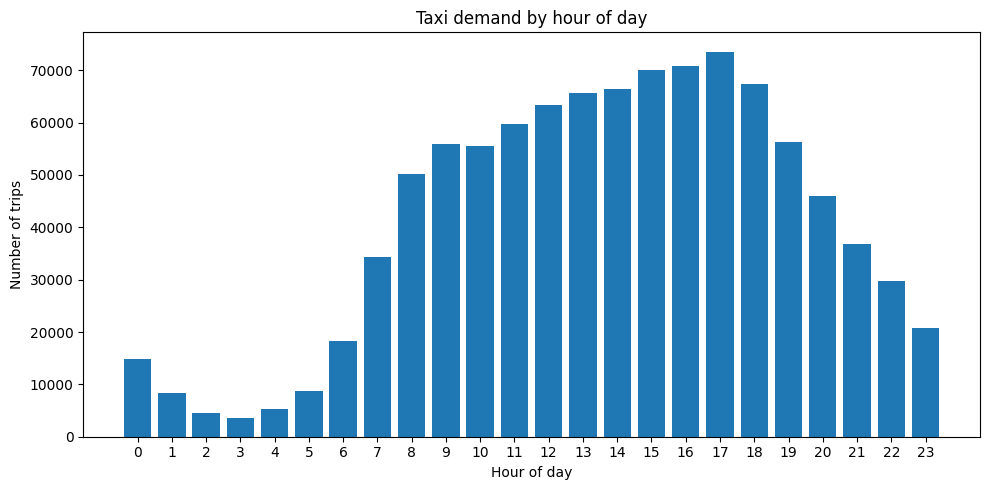

In [40]:
plt.figure(figsize=(10, 5))
plt.bar(demand_by_hour["hour"], demand_by_hour["trips"])
plt.xlabel("Hour of day")
plt.ylabel("Number of trips")
plt.title("Taxi demand by hour of day")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

In [41]:
hourly_demand = (
    df_temporal
    .groupby("time_bucket_hour")
    .size()
    .reset_index(name="trips")
)

hourly_demand["hour"] = hourly_demand["time_bucket_hour"].dt.hour
hourly_demand["date"] = hourly_demand["time_bucket_hour"].dt.date
hourly_demand["day_of_week"] = hourly_demand["time_bucket_hour"].dt.dayofweek
hourly_demand["day_name"] = hourly_demand["time_bucket_hour"].dt.day_name()
hourly_demand["is_weekend"] = hourly_demand["day_of_week"].isin([5, 6]).astype(int)
hourly_demand["month"] = hourly_demand["time_bucket_hour"].dt.month

avg_demand_by_hour = (
    hourly_demand
    .groupby("hour")["trips"]
    .mean()
    .reset_index(name="avg_trips_per_hour")
)

avg_demand_by_hour

,hour,avg_trips_per_hour
0,0,248.633333
1,1,137.950000
2,2,75.900000
3,3,60.833333
4,4,87.333333
5,5,146.833333
6,6,303.633333
7,7,570.966667
8,8,834.816667
9,9,932.166667


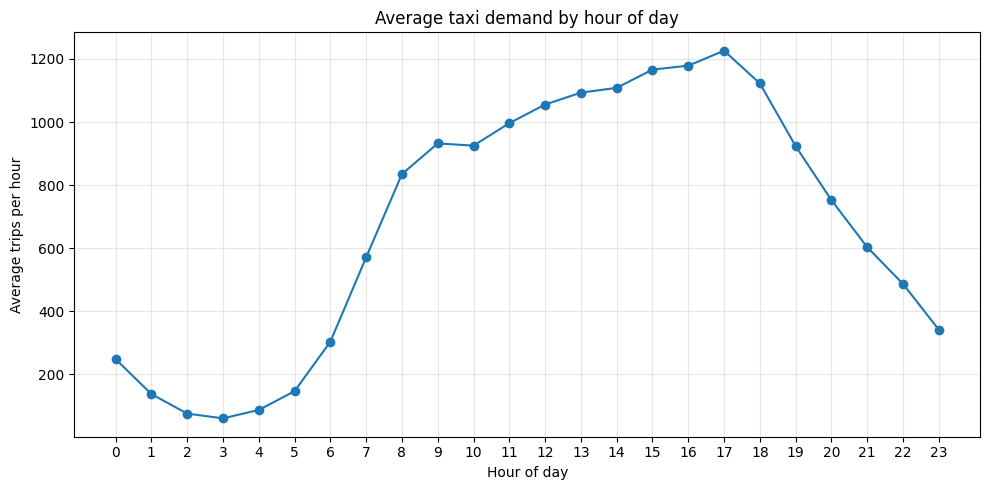

In [42]:
plt.figure(figsize=(10, 5))
plt.plot(avg_demand_by_hour["hour"], avg_demand_by_hour["avg_trips_per_hour"], marker="o")
plt.xlabel("Hour of day")
plt.ylabel("Average trips per hour")
plt.title("Average taxi demand by hour of day")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [43]:
weekend_demand = (
    df_temporal
    .groupby("is_weekend")
    .size()
    .reset_index(name="trips")
)

weekend_demand["day_type"] = weekend_demand["is_weekend"].map({
    0: "Weekday",
    1: "Weekend"
})

weekend_demand

,is_weekend,trips,day_type
0,0,750515,Weekday
1,1,235256,Weekend


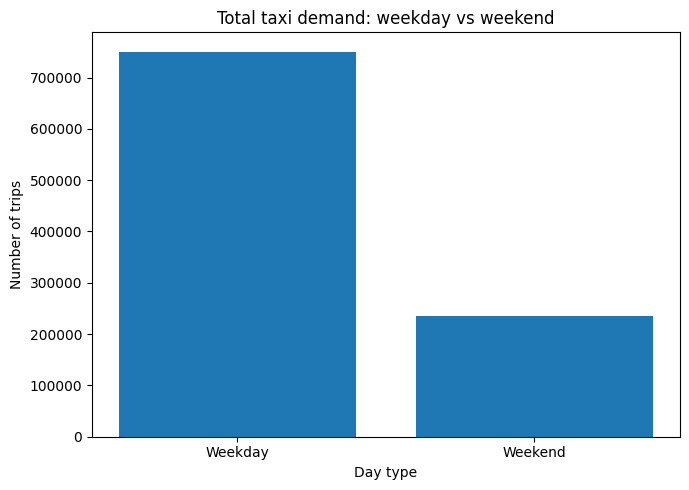

In [44]:
plt.figure(figsize=(7, 5))
plt.bar(weekend_demand["day_type"], weekend_demand["trips"])
plt.xlabel("Day type")
plt.ylabel("Number of trips")
plt.title("Total taxi demand: weekday vs weekend")
plt.tight_layout()
plt.show()

In [45]:
avg_weekend_demand = (
    hourly_demand
    .groupby("is_weekend")["trips"]
    .mean()
    .reset_index(name="avg_trips_per_hour")
)

avg_weekend_demand["day_type"] = avg_weekend_demand["is_weekend"].map({
    0: "Weekday",
    1: "Weekend"
})

avg_weekend_demand

,is_weekend,avg_trips_per_hour,day_type
0,0,740.883514,Weekday
1,1,544.574074,Weekend


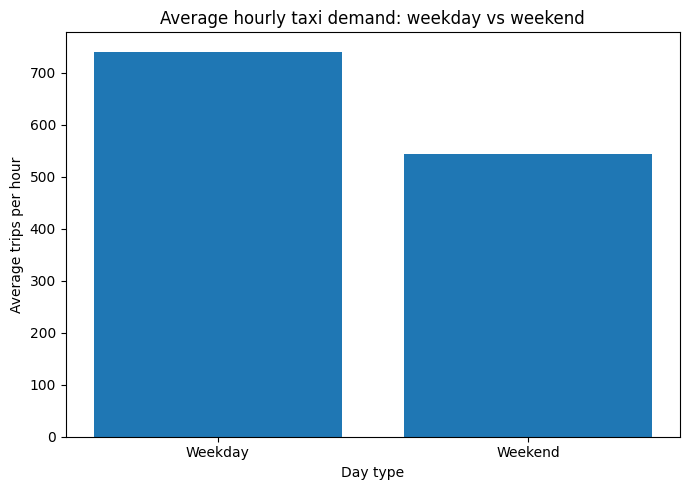

In [46]:
plt.figure(figsize=(7, 5))
plt.bar(avg_weekend_demand["day_type"], avg_weekend_demand["avg_trips_per_hour"])
plt.xlabel("Day type")
plt.ylabel("Average trips per hour")
plt.title("Average hourly taxi demand: weekday vs weekend")
plt.tight_layout()
plt.show()

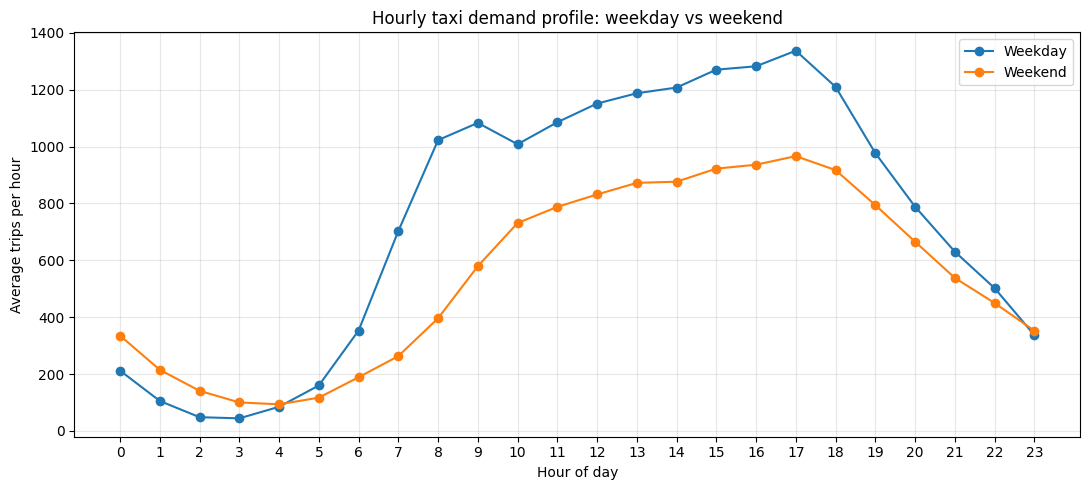

In [47]:
hour_weekend_profile = (
    hourly_demand
    .groupby(["is_weekend", "hour"])["trips"]
    .mean()
    .reset_index(name="avg_trips_per_hour")
)

weekday_profile = hour_weekend_profile[hour_weekend_profile["is_weekend"] == 0]
weekend_profile = hour_weekend_profile[hour_weekend_profile["is_weekend"] == 1]

plt.figure(figsize=(11, 5))
plt.plot(
    weekday_profile["hour"],
    weekday_profile["avg_trips_per_hour"],
    marker="o",
    label="Weekday"
)
plt.plot(
    weekend_profile["hour"],
    weekend_profile["avg_trips_per_hour"],
    marker="o",
    label="Weekend"
)
plt.xlabel("Hour of day")
plt.ylabel("Average trips per hour")
plt.title("Hourly taxi demand profile: weekday vs weekend")
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [48]:
weekday_hour = (
    hourly_demand
    .groupby(["day_of_week", "hour"])["trips"]
    .mean()
    .reset_index(name="avg_trips_per_hour")
)

heatmap_data = weekday_hour.pivot(
    index="day_of_week",
    columns="hour",
    values="avg_trips_per_hour"
)

heatmap_data = heatmap_data.reindex(range(7))
heatmap_data.index = weekday_order

heatmap_data

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Monday,216.111111,108.222222,45.444444,42.777778,89.333333,165.111111,348.888889,656.111111,979.000000,1086.666667,...,1168.111111,1226.444444,1209.888889,1214.888889,1062.888889,877.444444,700.555556,519.888889,393.000000,250.666667
Tuesday,202.333333,100.888889,43.333333,38.222222,79.888889,147.111111,337.333333,720.444444,1083.333333,1150.555556,...,1198.222222,1224.222222,1275.000000,1325.555556,1156.555556,937.444444,746.333333,546.555556,433.888889,275.444444
Wednesday,166.125000,74.875000,39.375000,41.500000,82.625000,157.875000,355.875000,766.625000,1085.125000,1158.125000,...,1251.625000,1291.750000,1290.000000,1363.250000,1203.875000,1002.125000,824.625000,650.250000,481.875000,288.625000
Thursday,194.875000,97.375000,49.375000,47.750000,81.000000,166.750000,373.500000,737.125000,1082.500000,1094.500000,...,1209.500000,1348.125000,1378.875000,1439.625000,1348.750000,1047.000000,867.750000,779.500000,645.250000,433.625000
Friday,279.750000,144.125000,63.875000,50.875000,90.875000,162.500000,351.375000,638.250000,882.125000,918.375000,...,1217.125000,1273.875000,1268.625000,1359.750000,1304.250000,1032.777778,817.000000,674.666667,570.555556,442.555556
Saturday,327.222222,208.777778,139.222222,96.555556,85.444444,104.888889,170.555556,252.000000,382.000000,570.555556,...,923.888889,942.000000,960.888889,1026.333333,1007.777778,865.888889,665.333333,582.333333,509.555556,430.888889
Sunday,342.333333,220.555556,142.333333,103.444444,101.333333,128.777778,206.777778,273.888889,410.222222,588.000000,...,829.222222,902.888889,911.666667,906.444444,827.000000,722.777778,665.666667,493.777778,390.111111,274.000000


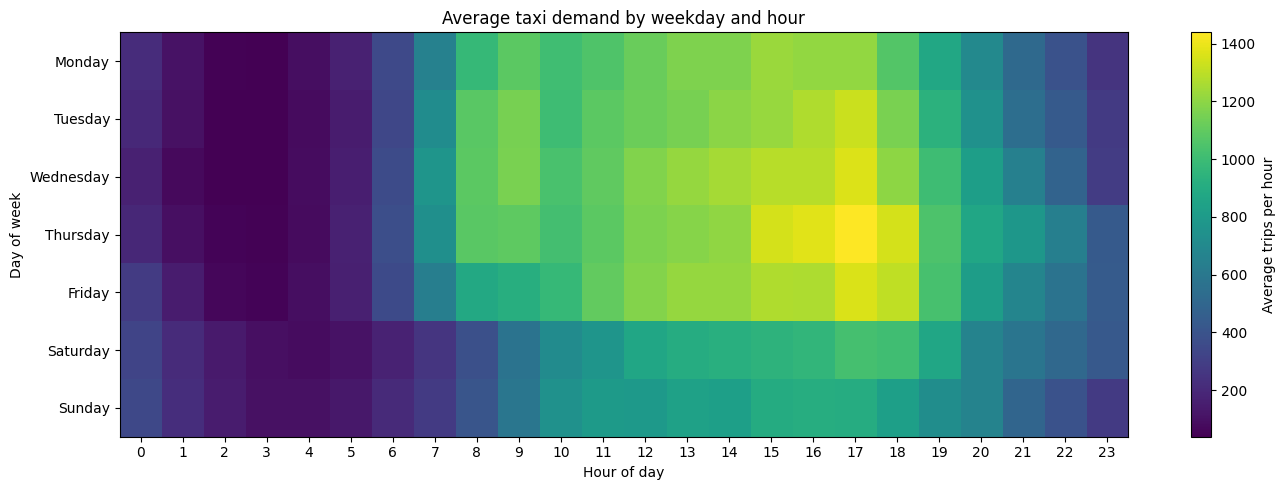

In [49]:
plt.figure(figsize=(14, 5))
plt.imshow(heatmap_data, aspect="auto")
plt.colorbar(label="Average trips per hour")
plt.xticks(ticks=np.arange(24), labels=np.arange(24))
plt.yticks(ticks=np.arange(7), labels=weekday_order)
plt.xlabel("Hour of day")
plt.ylabel("Day of week")
plt.title("Average taxi demand by weekday and hour")
plt.tight_layout()
plt.show()

In [50]:
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

demand_by_month = (
    df_temporal
    .groupby("month_name")
    .size()
    .reindex(month_order)
    .reset_index(name="trips")
)

demand_by_month

,month_name,trips
0,January,NaN
1,February,NaN
2,March,NaN
3,April,NaN
4,May,NaN
5,June,NaN
6,July,NaN
7,August,NaN
8,September,NaN
9,October,NaN


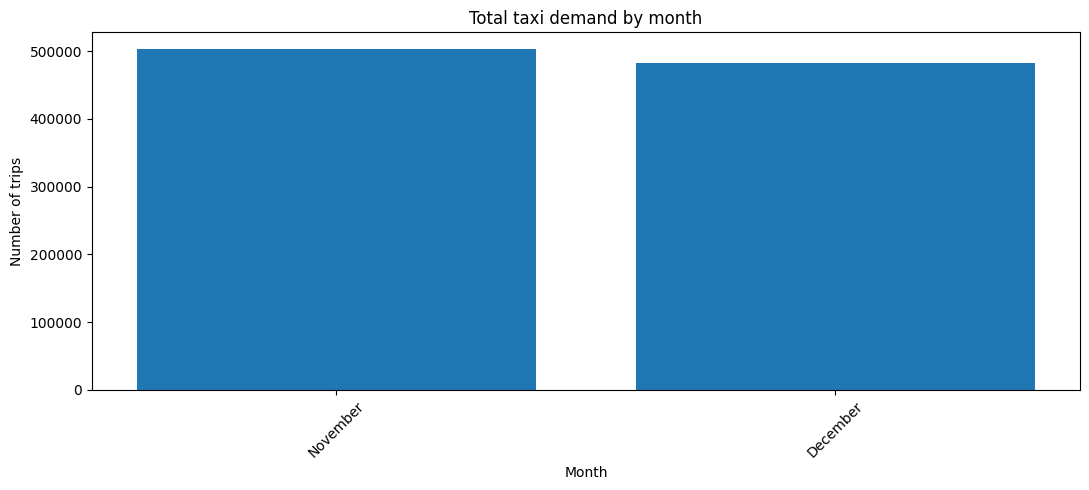

In [51]:
plt.figure(figsize=(11, 5))
plt.bar(demand_by_month["month_name"], demand_by_month["trips"])
plt.xlabel("Month")
plt.ylabel("Number of trips")
plt.title("Total taxi demand by month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [52]:
daily_demand = (
    df_temporal
    .groupby("date")
    .size()
    .reset_index(name="trips")
)

daily_demand["date"] = pd.to_datetime(daily_demand["date"])
daily_demand["month"] = daily_demand["date"].dt.month
daily_demand["month_name"] = daily_demand["date"].dt.month_name()
daily_demand["day_of_week"] = daily_demand["date"].dt.dayofweek
daily_demand["day_name"] = daily_demand["date"].dt.day_name()
daily_demand["is_weekend"] = daily_demand["day_of_week"].isin([5, 6]).astype(int)

avg_daily_by_month = (
    daily_demand
    .groupby("month_name")["trips"]
    .mean()
    .reindex(month_order)
    .reset_index(name="avg_trips_per_day")
)

avg_daily_by_month

,month_name,avg_trips_per_day
0,January,NaN
1,February,NaN
2,March,NaN
3,April,NaN
4,May,NaN
5,June,NaN
6,July,NaN
7,August,NaN
8,September,NaN
9,October,NaN


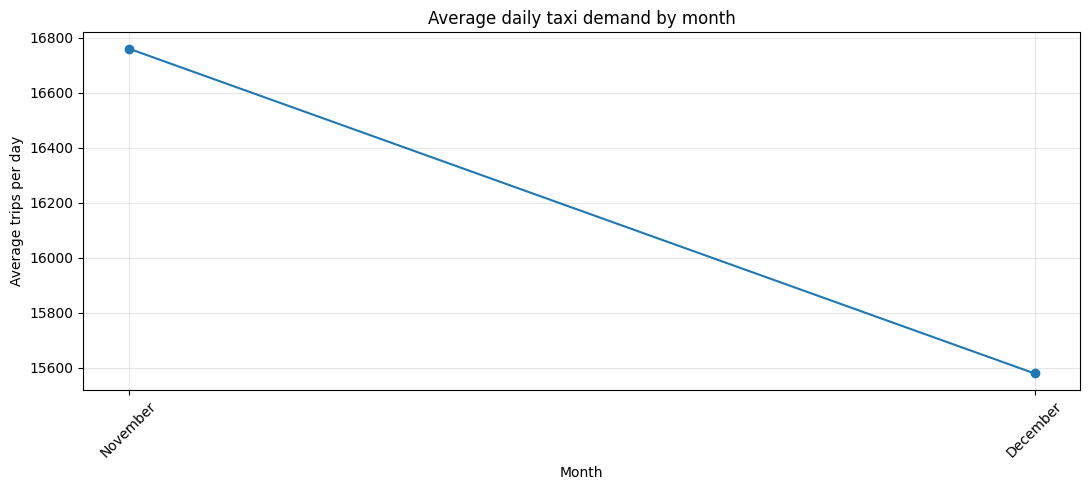

In [53]:
plt.figure(figsize=(11, 5))
plt.plot(avg_daily_by_month["month_name"], avg_daily_by_month["avg_trips_per_day"], marker="o")
plt.xlabel("Month")
plt.ylabel("Average trips per day")
plt.title("Average daily taxi demand by month")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

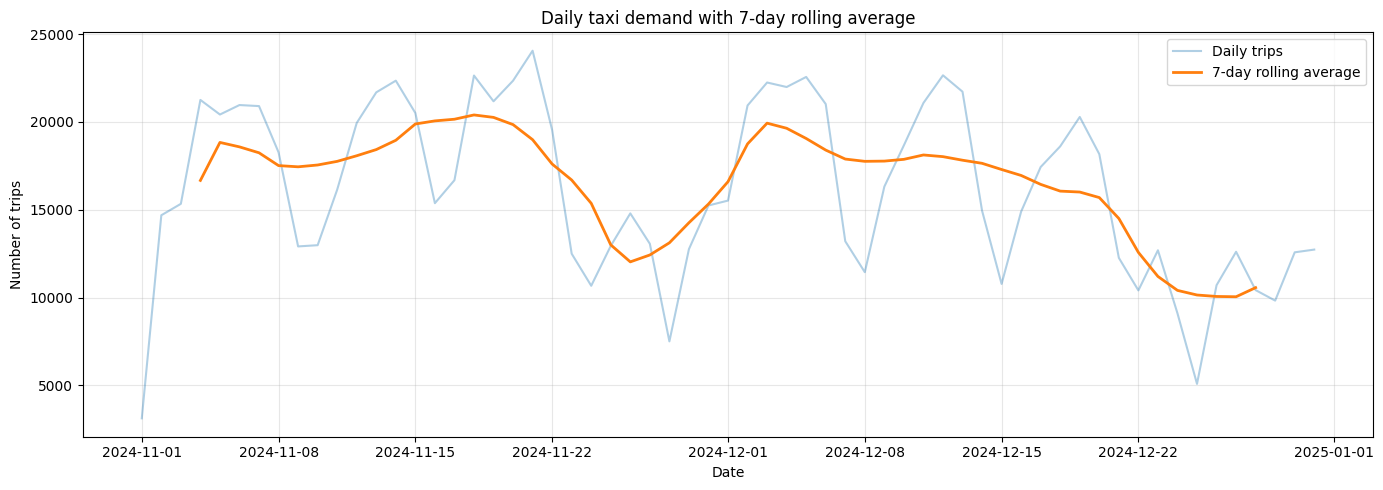

In [54]:
daily_demand = daily_demand.sort_values("date").copy()
daily_demand["trips_7d_rolling"] = daily_demand["trips"].rolling(window=7, center=True).mean()

plt.figure(figsize=(14, 5))
plt.plot(daily_demand["date"], daily_demand["trips"], alpha=0.35, label="Daily trips")
plt.plot(daily_demand["date"], daily_demand["trips_7d_rolling"], linewidth=2, label="7-day rolling average")
plt.xlabel("Date")
plt.ylabel("Number of trips")
plt.title("Daily taxi demand with 7-day rolling average")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [55]:
top_days = daily_demand.sort_values("trips", ascending=False).head(20)
top_days

,date,trips,month,month_name,day_of_week,day_name,is_weekend,trips_7d_rolling
20,2024-11-21,24054,11,November,3,Thursday,0,18990.000000
41,2024-12-12,22654,12,December,3,Thursday,0,18024.714286
17,2024-11-18,22641,11,November,0,Monday,0,20398.000000
34,2024-12-05,22561,12,December,3,Thursday,0,19058.000000
13,2024-11-14,22349,11,November,3,Thursday,0,18956.000000
19,2024-11-20,22348,11,November,2,Wednesday,0,19848.428571
32,2024-12-03,22244,12,December,1,Tuesday,0,19930.857143
33,2024-12-04,21988,12,December,2,Wednesday,0,19640.142857
42,2024-12-13,21722,12,December,4,Friday,0,17821.714286
12,2024-11-13,21685,11,November,2,Wednesday,0,18427.571429


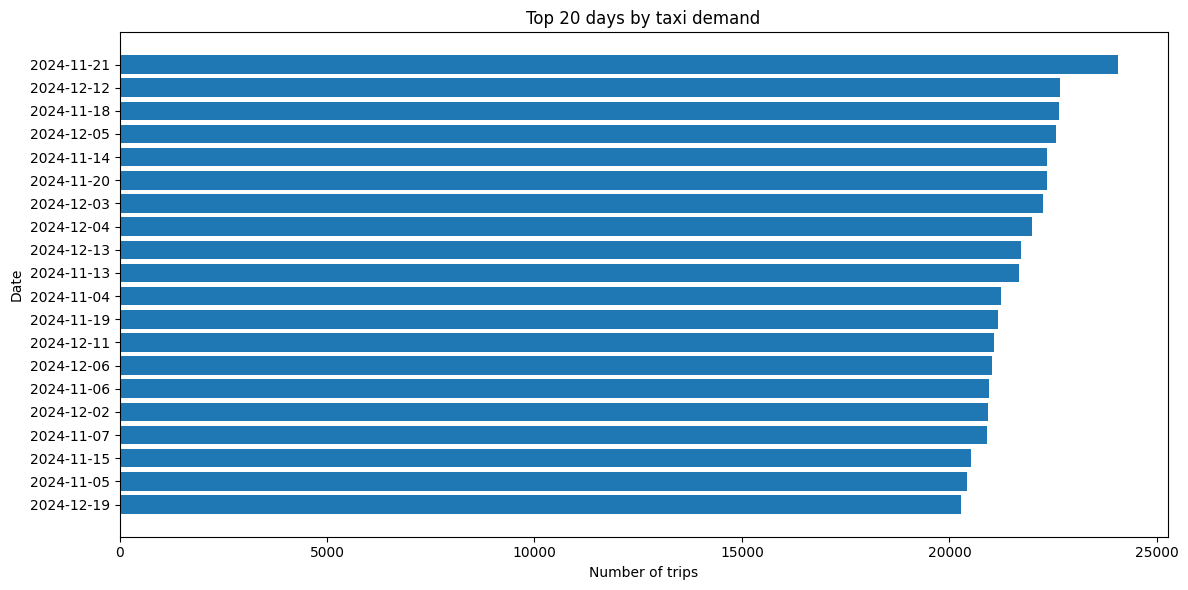

In [56]:
plt.figure(figsize=(12, 6))
plt.barh(top_days["date"].dt.strftime("%Y-%m-%d")[::-1], top_days["trips"][::-1])
plt.xlabel("Number of trips")
plt.ylabel("Date")
plt.title("Top 20 days by taxi demand")
plt.tight_layout()
plt.show()

In [57]:
low_days = daily_demand.sort_values("trips", ascending=True).head(20)
low_days

,date,trips,month,month_name,day_of_week,day_name,is_weekend,trips_7d_rolling
0,2024-11-01,3130,11,November,4,Friday,0,NaN
54,2024-12-25,5091,12,December,2,Wednesday,0,10150.000000
27,2024-11-28,7510,11,November,3,Thursday,0,13121.000000
53,2024-12-24,9108,12,December,1,Tuesday,0,10412.428571
58,2024-12-29,9831,12,December,6,Sunday,1,NaN
51,2024-12-22,10412,12,December,6,Sunday,1,12574.714286
57,2024-12-28,10428,12,December,5,Saturday,1,10568.571429
23,2024-11-24,10675,11,November,6,Sunday,1,15367.571429
55,2024-12-26,10706,12,December,3,Thursday,0,10067.000000
44,2024-12-15,10780,12,December,6,Sunday,1,17292.857143


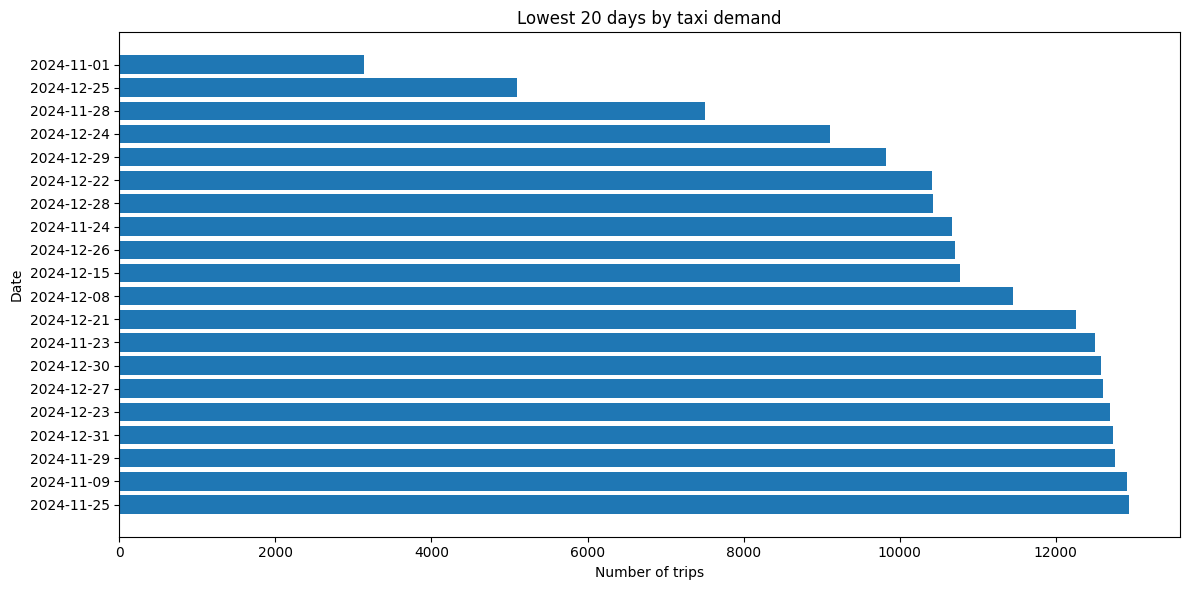

In [58]:
plt.figure(figsize=(12, 6))
plt.barh(low_days["date"].dt.strftime("%Y-%m-%d")[::-1], low_days["trips"][::-1])
plt.xlabel("Number of trips")
plt.ylabel("Date")
plt.title("Lowest 20 days by taxi demand")
plt.tight_layout()
plt.show()

detect outliers using z_score

In [59]:
daily_demand["z_score"] = (
    daily_demand["trips"] - daily_demand["trips"].mean()
) / daily_demand["trips"].std()

unusual_high_days = daily_demand[daily_demand["z_score"] > 2].sort_values("z_score", ascending=False)
unusual_low_days = daily_demand[daily_demand["z_score"] < -2].sort_values("z_score", ascending=True)

print("Unusually high demand days:")
display(unusual_high_days[["date", "trips", "z_score", "day_name"]])

print("Unusually low demand days:")
display(unusual_low_days[["date", "trips", "z_score", "day_name"]])

Unusually high demand days:


,date,trips,z_score,day_name


Unusually low demand days:


,date,trips,z_score,day_name
0,2024-11-01,3130,-2.652275,Friday
54,2024-12-25,5091,-2.253116,Wednesday


In [62]:
daily_demand["weekday_mean"] = daily_demand.groupby("day_of_week")["trips"].transform("mean")
daily_demand["weekday_std"] = daily_demand.groupby("day_of_week")["trips"].transform("std")

daily_demand["weekday_z_score"] = (
    daily_demand["trips"] - daily_demand["weekday_mean"]
) / daily_demand["weekday_std"]

weekday_unusual_high = daily_demand[daily_demand["weekday_z_score"] > 2].sort_values("weekday_z_score", ascending=False)
weekday_unusual_low = daily_demand[daily_demand["weekday_z_score"] < -2].sort_values("weekday_z_score", ascending=True)

print("Unusually high days relative to same weekday:")
display(weekday_unusual_high[["date", "day_name", "trips", "weekday_z_score"]])

print("Unusually low days relative to same weekday:")
display(weekday_unusual_low[["date", "day_name", "trips", "weekday_z_score"]])

Unusually high days relative to same weekday:


,date,day_name,trips,weekday_z_score


Unusually low days relative to same weekday:


,date,day_name,trips,weekday_z_score
0,2024-11-01,Friday,3130,-2.219024
54,2024-12-25,Wednesday,5091,-2.143711


Mark some known US holidays manually

In [63]:
holidays_2024 = {
    "2024-01-01": "New Year's Day",
    "2024-01-15": "Martin Luther King Jr. Day",
    "2024-02-19": "Presidents' Day",
    "2024-05-27": "Memorial Day",
    "2024-07-04": "Independence Day",
    "2024-09-02": "Labor Day",
    "2024-10-14": "Columbus Day",
    "2024-11-11": "Veterans Day",
    "2024-11-28": "Thanksgiving",
    "2024-12-25": "Christmas Day",
}

holiday_df = pd.DataFrame({
    "date": pd.to_datetime(list(holidays_2024.keys())),
    "holiday": list(holidays_2024.values())
})

daily_with_holidays = daily_demand.merge(holiday_df, on="date", how="left")

daily_with_holidays[daily_with_holidays["holiday"].notna()][
    ["date", "holiday", "day_name", "trips", "z_score", "weekday_z_score"]
]

,date,holiday,day_name,trips,z_score,weekday_z_score
10,2024-11-11,Veterans Day,Monday,16147,-0.002683,-0.143229
27,2024-11-28,Thanksgiving,Thursday,7510,-1.760732,-1.834600
54,2024-12-25,Christmas Day,Wednesday,5091,-2.253116,-2.143711


## spatial Demand Patterns

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make a spatial working copy
df_spatial = df_clean.copy()

# Ensure datetime
df_spatial["trip_start_dt"] = pd.to_datetime(df_spatial["trip_start_dt"], errors="coerce")

# Temporal features if not already present
df_spatial["hour"] = df_spatial["trip_start_dt"].dt.hour
df_spatial["day_of_week"] = df_spatial["trip_start_dt"].dt.dayofweek
df_spatial["day_name"] = df_spatial["trip_start_dt"].dt.day_name()
df_spatial["is_weekend"] = df_spatial["day_of_week"].isin([5, 6]).astype(int)

# Chicago-ish bounding box for plotting
CHICAGO_LAT_MIN = 41.60
CHICAGO_LAT_MAX = 42.10
CHICAGO_LON_MIN = -88.00
CHICAGO_LON_MAX = -87.40

# Keep only rows with valid pickup coordinates
df_spatial = df_spatial[
    df_spatial["pickup_lat"].between(CHICAGO_LAT_MIN, CHICAGO_LAT_MAX)
    & df_spatial["pickup_lon"].between(CHICAGO_LON_MIN, CHICAGO_LON_MAX)
].copy()

print("Spatial dataset rows:", f"{len(df_spatial):,}")
print("Pickup lat range:", df_spatial["pickup_lat"].min(), df_spatial["pickup_lat"].max())
print("Pickup lon range:", df_spatial["pickup_lon"].min(), df_spatial["pickup_lon"].max())

Spatial dataset rows: 985,771
Pickup lat range: 41.660136051 42.021223593
Pickup lon range: -87.913624596 -87.531386257


In [65]:
pickup_area_demand = (
    df_spatial
    .groupby("pickup_community_area")
    .size()
    .reset_index(name="pickup_trips")
    .sort_values("pickup_trips", ascending=False)
)

pickup_area_demand.head(20)

,pickup_community_area,pickup_trips
7,8,221761
75,76,199982
31,32,162445
27,28,98592
32,33,40904
5,6,31011
55,56,30845
6,7,21650
2,3,16487
76,77,12561


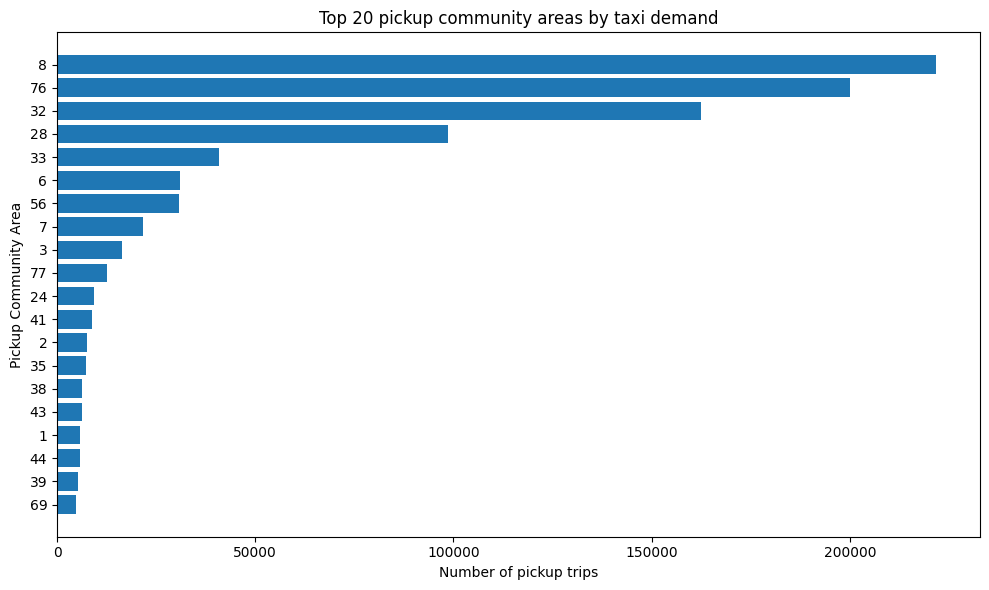

In [66]:
top_pickup_areas = pickup_area_demand.head(20)

plt.figure(figsize=(10, 6))
plt.barh(
    top_pickup_areas["pickup_community_area"].astype(str)[::-1],
    top_pickup_areas["pickup_trips"][::-1]
)
plt.xlabel("Number of pickup trips")
plt.ylabel("Pickup Community Area")
plt.title("Top 20 pickup community areas by taxi demand")
plt.tight_layout()
plt.show()

In [67]:
pickup_tract_demand = (
    df_spatial
    .dropna(subset=["pickup_census_tract"])
    .groupby("pickup_census_tract")
    .size()
    .reset_index(name="pickup_trips")
    .sort_values("pickup_trips", ascending=False)
)

pickup_tract_demand.head(20)

,pickup_census_tract,pickup_trips
287,17031980000,97822
271,17031839100,48238
158,17031320100,47266
153,17031281900,36601
99,17031081500,28847
161,17031330100,19076
96,17031081401,18364
98,17031081403,15134
151,17031280100,15080
288,17031980100,14084


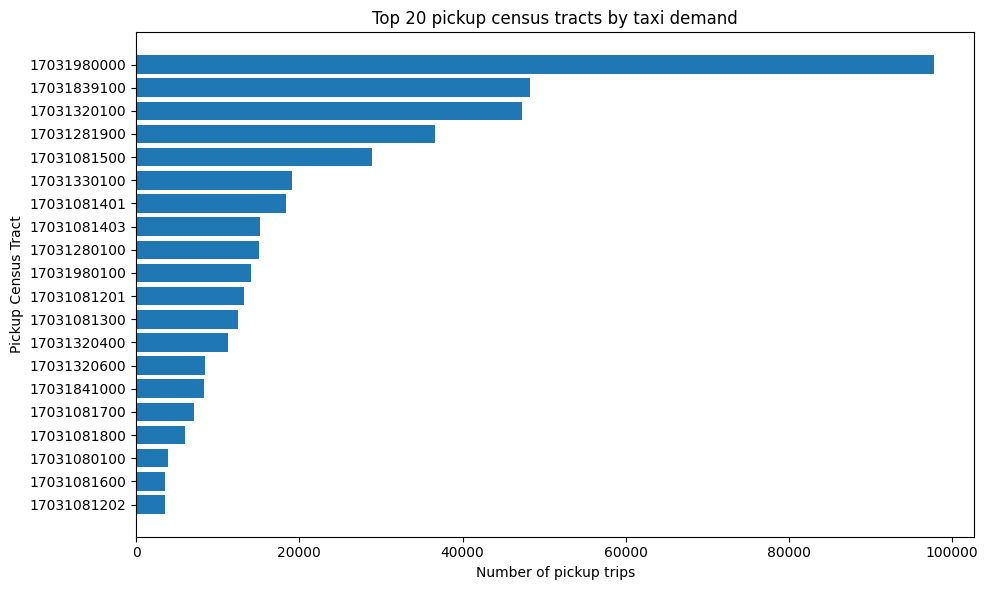

In [68]:
top_pickup_tracts = pickup_tract_demand.head(20)

plt.figure(figsize=(10, 6))
plt.barh(
    top_pickup_tracts["pickup_census_tract"].astype("Int64").astype(str)[::-1],
    top_pickup_tracts["pickup_trips"][::-1]
)
plt.xlabel("Number of pickup trips")
plt.ylabel("Pickup Census Tract")
plt.title("Top 20 pickup census tracts by taxi demand")
plt.tight_layout()
plt.show()

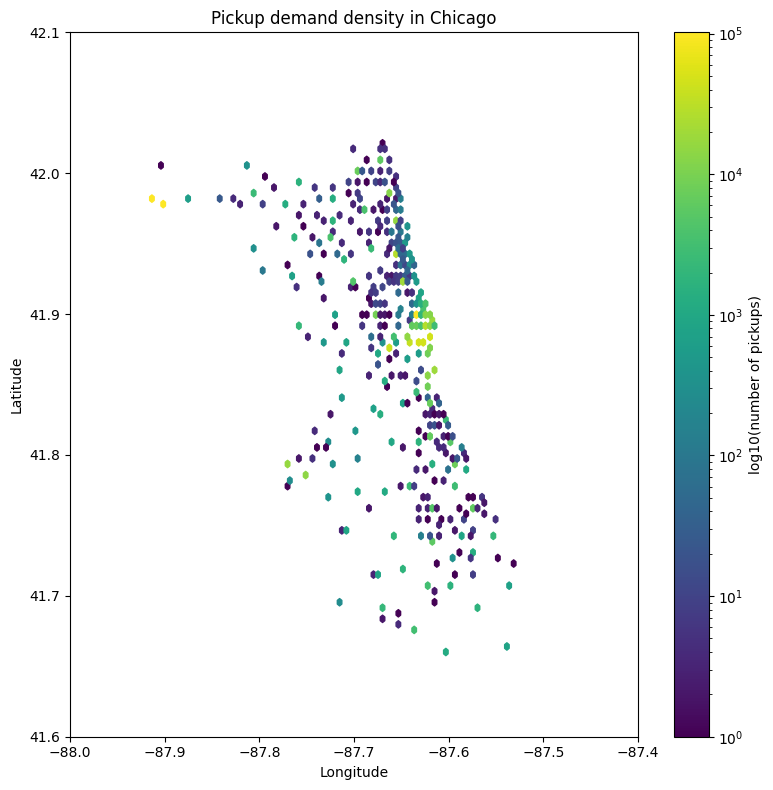

In [69]:
plt.figure(figsize=(8, 8))
plt.hexbin(
    df_spatial["pickup_lon"],
    df_spatial["pickup_lat"],
    gridsize=80,
    mincnt=1,
    bins="log"
)
plt.colorbar(label="log10(number of pickups)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Pickup demand density in Chicago")
plt.xlim(CHICAGO_LON_MIN, CHICAGO_LON_MAX)
plt.ylim(CHICAGO_LAT_MIN, CHICAGO_LAT_MAX)
plt.tight_layout()
plt.show()

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import h3
import geopandas as gpd
from shapely.geometry import Polygon

In [71]:
spatial_cols = [
    "pickup_lat",
    "pickup_lon",
    "dropoff_lat",
    "dropoff_lon",
    "pickup_community_area",
    "dropoff_community_area",
    "pickup_census_tract",
    "dropoff_census_tract",
]

df_clean[spatial_cols].head()

,pickup_lat,pickup_lon,dropoff_lat,dropoff_lon,pickup_community_area,dropoff_community_area,pickup_census_tract,dropoff_census_tract
0,41.706588,-87.623367,41.899602,-87.633308,49,8,<NA>,<NA>
1,41.980264,-87.913625,<NA>,<NA>,76,<NA>,<NA>,<NA>
2,41.899602,-87.633308,41.965812,-87.655879,8,3,<NA>,<NA>
3,41.901207,-87.676356,41.901207,-87.676356,24,24,<NA>,<NA>
4,41.980264,-87.913625,<NA>,<NA>,76,<NA>,<NA>,<NA>


In [72]:
df_clean[spatial_cols].isna().mean().sort_values(ascending=False)

dropoff_census_tract      0.563858
pickup_census_tract       0.550628
dropoff_community_area    0.068565
dropoff_lat               0.063155
dropoff_lon               0.063155
pickup_community_area     0.000628
pickup_lat                0.000000
pickup_lon                0.000000
dtype: float64

In [73]:
df_spatial = df_clean.copy()

df_spatial = df_spatial[
    df_spatial["pickup_lat"].notna()
    & df_spatial["pickup_lon"].notna()
    & df_spatial["pickup_lat"].between(41.60, 42.10)
    & df_spatial["pickup_lon"].between(-88.00, -87.40)
].copy()

print("Rows for spatial analysis:", f"{len(df_spatial):,}")

Rows for spatial analysis: 985,771


In [74]:
df_spatial_od = df_spatial[
    df_spatial["dropoff_lat"].notna()
    & df_spatial["dropoff_lon"].notna()
    & df_spatial["dropoff_lat"].between(41.60, 42.10)
    & df_spatial["dropoff_lon"].between(-88.00, -87.40)
].copy()

print("Rows with pickup and dropoff coordinates:", f"{len(df_spatial_od):,}")
print("Share with valid dropoff:", f"{len(df_spatial_od) / len(df_spatial) * 100:.2f}%")

Rows with pickup and dropoff coordinates: 923,515
Share with valid dropoff: 93.68%


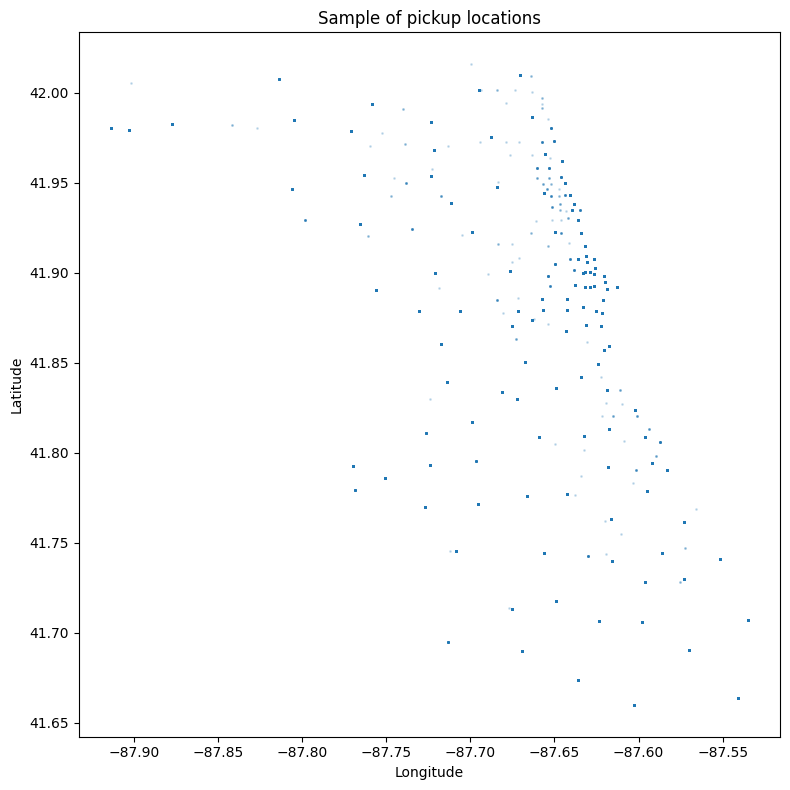

In [75]:
sample_size = min(100_000, len(df_spatial))
df_sample = df_spatial.sample(sample_size, random_state=42)

plt.figure(figsize=(8, 8))
plt.scatter(
    df_sample["pickup_lon"],
    df_sample["pickup_lat"],
    s=1,
    alpha=0.2
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Sample of pickup locations")
plt.tight_layout()
plt.show()

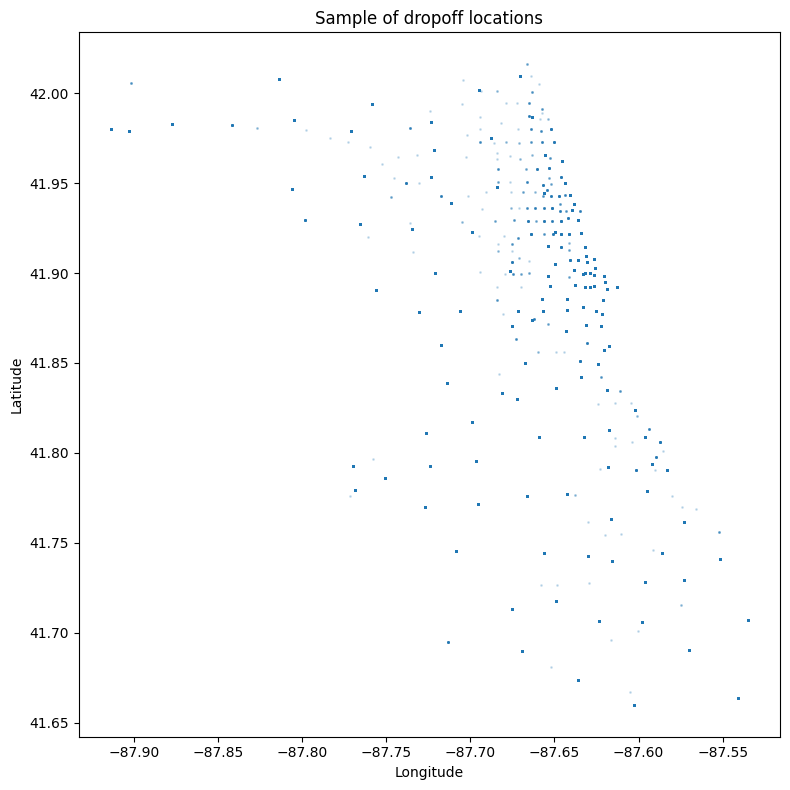

In [76]:
sample_size = min(100_000, len(df_spatial_od))
df_od_sample = df_spatial_od.sample(sample_size, random_state=42)

plt.figure(figsize=(8, 8))
plt.scatter(
    df_od_sample["dropoff_lon"],
    df_od_sample["dropoff_lat"],
    s=1,
    alpha=0.2
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Sample of dropoff locations")
plt.tight_layout()
plt.show()

In [77]:
H3_RESOLUTION = 8

def latlon_to_h3(lat, lon, resolution=H3_RESOLUTION):
    if pd.isna(lat) or pd.isna(lon):
        return pd.NA
    return h3.latlng_to_cell(lat, lon, resolution)

In [78]:
df_spatial["pickup_h3"] = [
    latlon_to_h3(lat, lon, H3_RESOLUTION)
    for lat, lon in zip(df_spatial["pickup_lat"], df_spatial["pickup_lon"])
]

df_spatial[["pickup_lat", "pickup_lon", "pickup_h3"]].head()

,pickup_lat,pickup_lon,pickup_h3
0,41.706588,-87.623367,8826645641fffff
1,41.980264,-87.913625,8827593433fffff
2,41.899602,-87.633308,882664c1edfffff
3,41.901207,-87.676356,882664cac3fffff
4,41.980264,-87.913625,8827593433fffff


In [79]:
df_spatial_od["pickup_h3"] = [
    latlon_to_h3(lat, lon, H3_RESOLUTION)
    for lat, lon in zip(df_spatial_od["pickup_lat"], df_spatial_od["pickup_lon"])
]

df_spatial_od["dropoff_h3"] = [
    latlon_to_h3(lat, lon, H3_RESOLUTION)
    for lat, lon in zip(df_spatial_od["dropoff_lat"], df_spatial_od["dropoff_lon"])
]

df_spatial_od[["pickup_h3", "dropoff_h3"]].head()

,pickup_h3,dropoff_h3
0,8826645641fffff,882664c1edfffff
2,882664c1edfffff,882664d897fffff
3,882664cac3fffff,882664cac3fffff
5,8827593433fffff,8827593433fffff
6,882664ca91fffff,882664c1a9fffff


In [80]:
pickup_h3_demand = (
    df_spatial
    .groupby("pickup_h3")
    .size()
    .reset_index(name="pickup_demand")
    .sort_values("pickup_demand", ascending=False)
)

pickup_h3_demand.head(20)

,pickup_h3,pickup_demand
64,882664c1edfffff,108867
257,8827593433fffff,102135
259,88275934edfffff,97822
53,882664c1a9fffff,94919
59,882664c1e3fffff,62400
55,882664c1adfffff,51681
58,882664c1e1fffff,45619
97,882664ca91fffff,41040
46,882664c163fffff,28878
63,882664c1ebfffff,21230


In [81]:
print("Number of pickup hexagons:", pickup_h3_demand["pickup_h3"].nunique())
print("Total pickup trips:", pickup_h3_demand["pickup_demand"].sum())
print("Mean demand per hexagon:", pickup_h3_demand["pickup_demand"].mean())
print("Median demand per hexagon:", pickup_h3_demand["pickup_demand"].median())

Number of pickup hexagons: 267
Total pickup trips: 985771
Mean demand per hexagon: 3692.0262172284642
Median demand per hexagon: 24.0


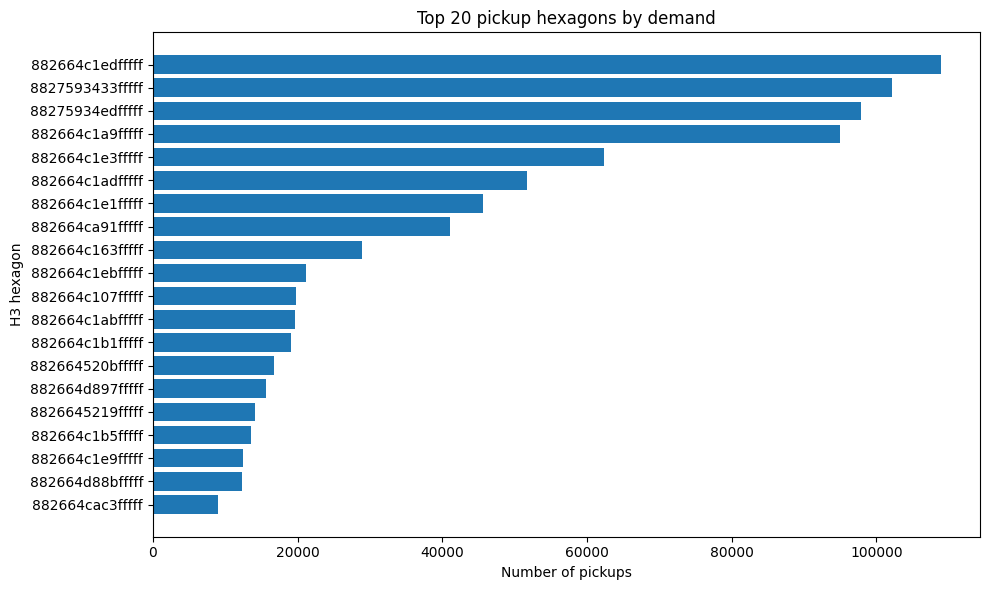

In [82]:
top_pickup_h3 = pickup_h3_demand.head(20).copy()

plt.figure(figsize=(10, 6))
plt.barh(
    top_pickup_h3["pickup_h3"].astype(str)[::-1],
    top_pickup_h3["pickup_demand"][::-1]
)
plt.xlabel("Number of pickups")
plt.ylabel("H3 hexagon")
plt.title("Top 20 pickup hexagons by demand")
plt.tight_layout()
plt.show()

In [83]:
def h3_to_polygon(cell):
    boundary = h3.cell_to_boundary(cell)
    # h3 returns lat/lon; shapely wants lon/lat
    return Polygon([(lon, lat) for lat, lon in boundary])

In [84]:
pickup_h3_gdf = pickup_h3_demand.copy()
pickup_h3_gdf["geometry"] = pickup_h3_gdf["pickup_h3"].apply(h3_to_polygon)

pickup_h3_gdf = gpd.GeoDataFrame(
    pickup_h3_gdf,
    geometry="geometry",
    crs="EPSG:4326"
)

pickup_h3_gdf.head()

,pickup_h3,pickup_demand,geometry
64,882664c1edfffff,108867,"POLYGON ((-87.63049 41.90755, -87.63653 41.905..."
257,8827593433fffff,102135,"POLYGON ((-87.9157 41.98264, -87.92174 41.9808..."
259,88275934edfffff,97822,"POLYGON ((-87.90424 41.98162, -87.91028 41.979..."
53,882664c1a9fffff,94919,"POLYGON ((-87.62769 41.8861, -87.63373 41.8842..."
59,882664c1e3fffff,62400,"POLYGON ((-87.621 41.89255, -87.62704 41.89075..."


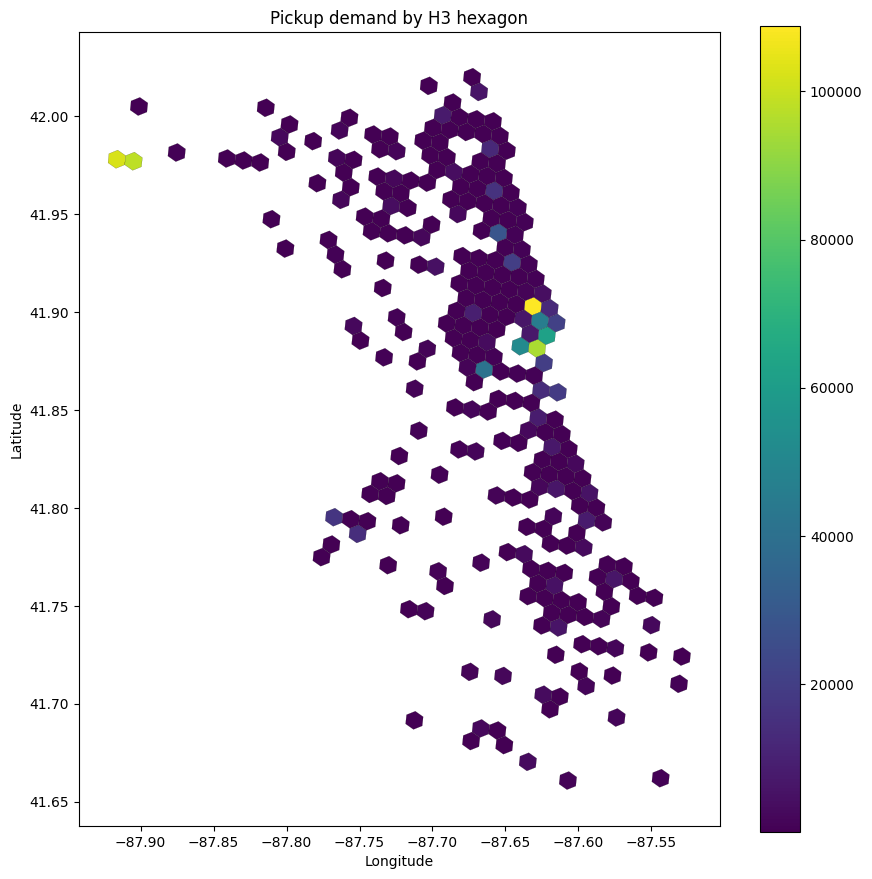

In [85]:
fig, ax = plt.subplots(figsize=(9, 9))

pickup_h3_gdf.plot(
    column="pickup_demand",
    ax=ax,
    legend=True,
    linewidth=0.1,
    edgecolor="black"
)

ax.set_title("Pickup demand by H3 hexagon")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

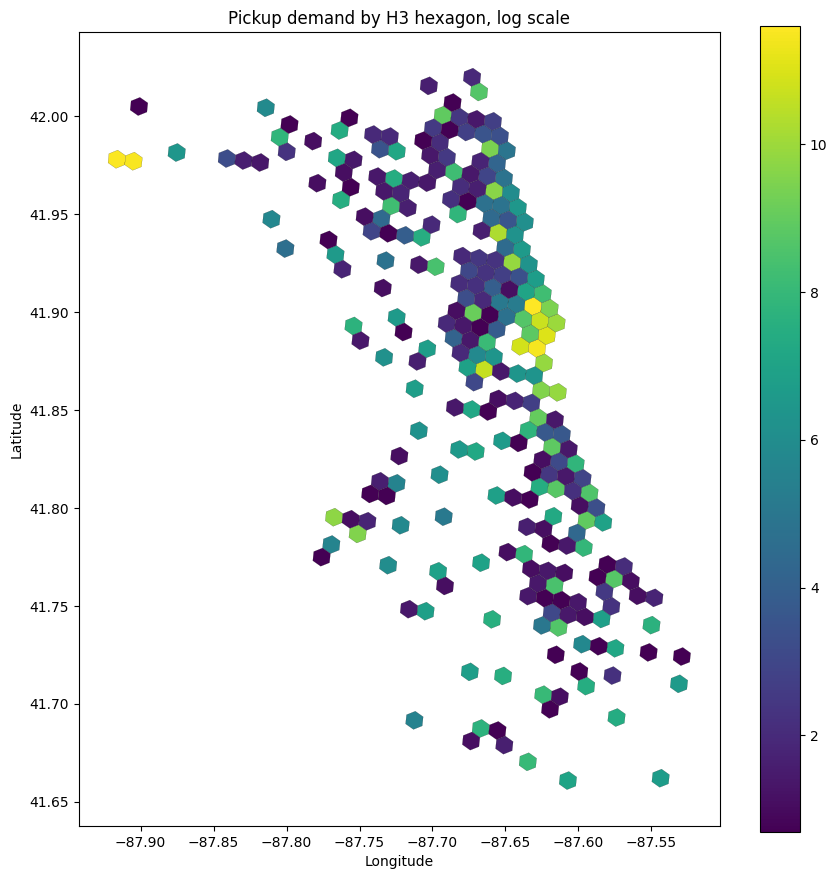

In [86]:
pickup_h3_gdf["log_pickup_demand"] = np.log1p(pickup_h3_gdf["pickup_demand"])

fig, ax = plt.subplots(figsize=(9, 9))

pickup_h3_gdf.plot(
    column="log_pickup_demand",
    ax=ax,
    legend=True,
    linewidth=0.1,
    edgecolor="black"
)

ax.set_title("Pickup demand by H3 hexagon, log scale")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

check for hotspots like aitports

In [87]:
ohare_h3 = latlon_to_h3(41.9742, -87.9073, H3_RESOLUTION)
midway_h3 = latlon_to_h3(41.7868, -87.7522, H3_RESOLUTION)

print("O'Hare H3:", ohare_h3)
print("Midway H3:", midway_h3)

O'Hare H3: 88275934edfffff
Midway H3: 8826645219fffff


In [88]:
airport_demand = pickup_h3_demand[
    pickup_h3_demand["pickup_h3"].isin([ohare_h3, midway_h3])
].copy()

airport_demand

,pickup_h3,pickup_demand
259,88275934edfffff,97822
6,8826645219fffff,14084
